# SkyGuard AI — Intelligent AWS Anomaly Detection

## Machine Learning Prototype

**Objective:**  
Detect abnormal Automatic Weather Station (AWS) observations and distinguish
likely sensor/data faults from normal observations using Quality Control,
Machine Learning, Multivariate Consistency and Evidence Fusion.

### Dataset
Maitri Automatic Weather Station Dataset — NCPOR / IMD

### Parameters
- Temperature
- Atmospheric Pressure
- Relative Humidity

### ML Models
- Isolation Forest
- LSTM Autoencoder

### Decision Framework
QC → ML Detection → Multivariate Validation → Evidence Fusion → Classification

## 1. Imports and Dataset Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("imd_maitri.csv")

df.columns = [
    "TIMESTAMP",
    "TEMPERATURE",
    "PRESSURE",
    "WIND_SPEED",
    "WIND_DIRECTION",
    "HUMIDITY"
]

df["TIMESTAMP"] = pd.to_datetime(
    df["TIMESTAMP"],
    errors="coerce"
)

# Preserve the raw file; convert the dataset's missing-value marker only in memory.
df = df.replace(-999, np.nan)

print("Raw dataset shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())


Raw dataset shape: (155170, 6)

Missing values:
TIMESTAMP              0
TEMPERATURE         8297
PRESSURE            8297
WIND_SPEED          8297
WIND_DIRECTION    138656
HUMIDITY          138656
dtype: int64


## 2. Dataset Selection and Audit

In [2]:
# Use the period in which all three SIH-required parameters are available.
skyguard_df = df[
    (df["TIMESTAMP"] >= "2015-01-01") &
    (df["TIMESTAMP"] <= "2016-12-19 12:00:00")
].copy()

skyguard_df = skyguard_df[
    ["TIMESTAMP", "TEMPERATURE", "PRESSURE", "HUMIDITY"]
].copy()

skyguard_df = (
    skyguard_df
    .sort_values("TIMESTAMP")
    .reset_index(drop=True)
)

print("SkyGuard observations:", len(skyguard_df))
print("\nTime range:")
print(skyguard_df["TIMESTAMP"].min(), "to", skyguard_df["TIMESTAMP"].max())

print("\nMissing values:")
print(skyguard_df.isna().sum())

print("\nDuplicate timestamps:",
      skyguard_df["TIMESTAMP"].duplicated().sum())

skyguard_df["TIME_DIFF"] = skyguard_df["TIMESTAMP"].diff()
gap_mask = skyguard_df["TIME_DIFF"] > pd.Timedelta(hours=1)

print("\nGap transitions:", int(gap_mask.sum()))
print("\nTime interval distribution:")
print(skyguard_df["TIME_DIFF"].value_counts().head(10))


SkyGuard observations: 16514

Time range:
2015-01-01 00:00:00 to 2016-12-19 12:00:00

Missing values:
TIMESTAMP      0
TEMPERATURE    0
PRESSURE       0
HUMIDITY       0
dtype: int64

Duplicate timestamps: 0

Gap transitions: 10

Time interval distribution:
TIME_DIFF
0 days 01:00:00    16503
5 days 01:00:00        3
0 days 19:00:00        1
0 days 10:00:00        1
6 days 01:00:00        1
0 days 22:00:00        1
7 days 09:00:00        1
0 days 02:00:00        1
0 days 03:00:00        1
Name: count, dtype: int64


In [3]:
print("Descriptive statistics:")
display(
    skyguard_df[
        ["TEMPERATURE", "PRESSURE", "HUMIDITY"]
    ].describe()
)


Descriptive statistics:


,TEMPERATURE,PRESSURE,HUMIDITY
count,16514.000000,16514.000000,16514.000000
mean,-9.010888,966.059398,51.184934
std,7.229372,9.428573,17.722573
min,-33.900000,927.900000,21.000000
25%,-14.000000,960.500000,38.000000
50%,-8.400000,966.600000,46.000000
75%,-3.200000,972.300000,59.000000
max,41.600000,996.600000,100.000000


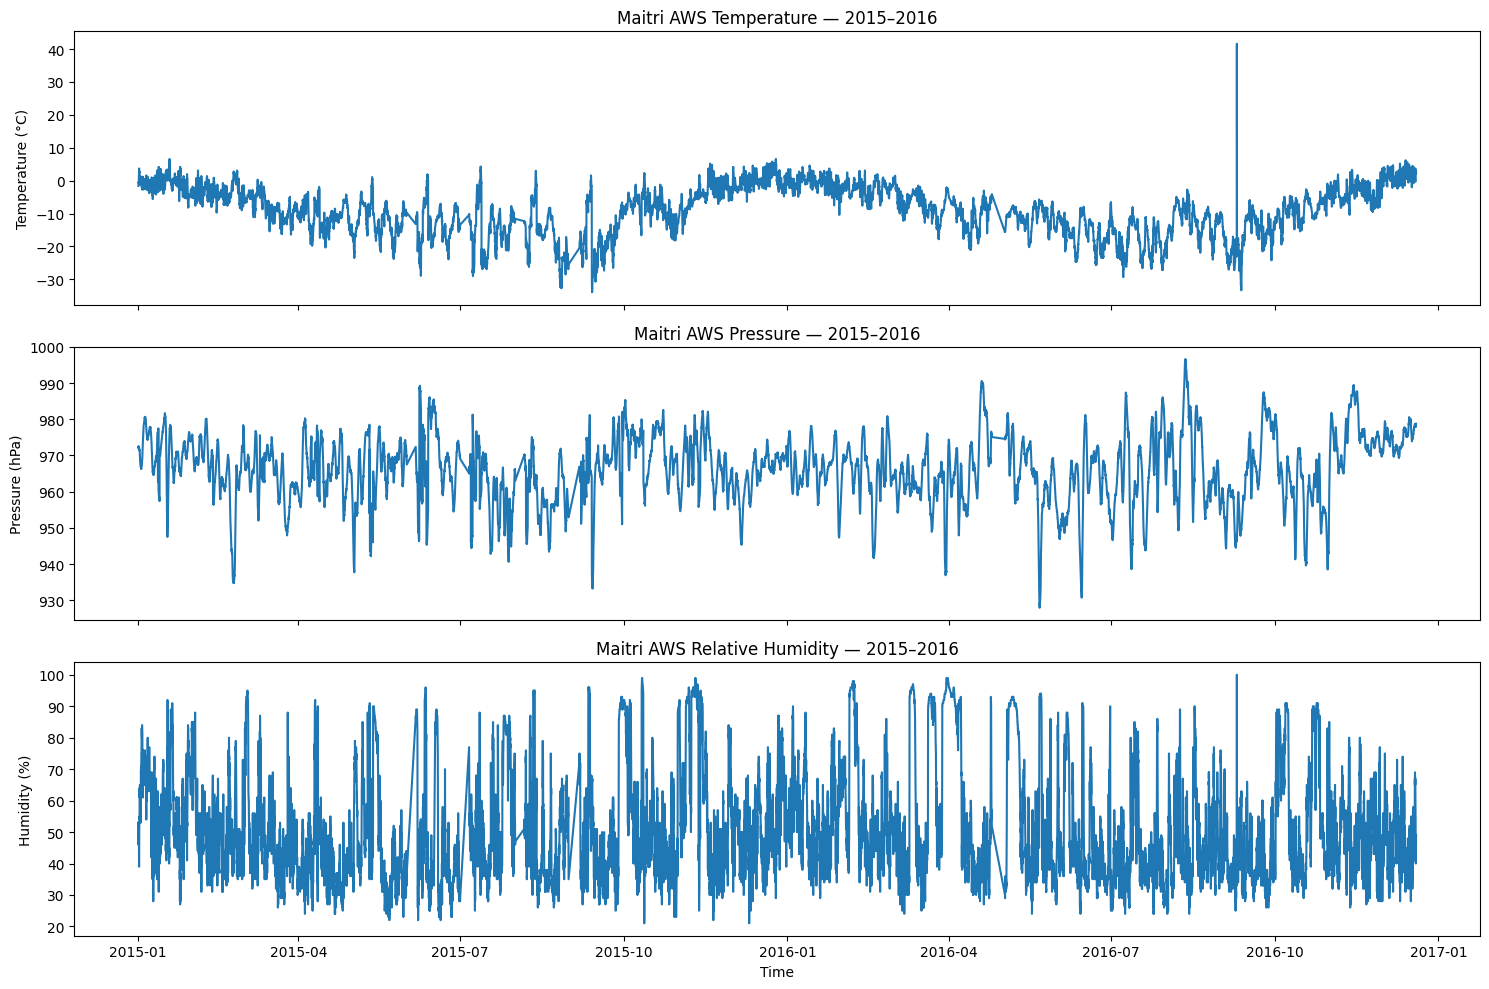

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

axes[0].plot(
    skyguard_df["TIMESTAMP"],
    skyguard_df["TEMPERATURE"]
)
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("Maitri AWS Temperature — 2015–2016")

axes[1].plot(
    skyguard_df["TIMESTAMP"],
    skyguard_df["PRESSURE"]
)
axes[1].set_ylabel("Pressure (hPa)")
axes[1].set_title("Maitri AWS Pressure — 2015–2016")

axes[2].plot(
    skyguard_df["TIMESTAMP"],
    skyguard_df["HUMIDITY"]
)
axes[2].set_ylabel("Humidity (%)")
axes[2].set_xlabel("Time")
axes[2].set_title("Maitri AWS Relative Humidity — 2015–2016")

plt.tight_layout()
plt.show()


In [5]:
event_idx = skyguard_df["TEMPERATURE"].idxmax()

print("Highest temperature observations:")
display(
    skyguard_df[
        ["TIMESTAMP", "TEMPERATURE", "PRESSURE", "HUMIDITY"]
    ]
    .sort_values("TEMPERATURE", ascending=False)
    .head(10)
)

print("\nObservations around the highest-temperature event:")
display(
    skyguard_df.loc[
        max(0, event_idx - 5):event_idx + 5,
        ["TIMESTAMP", "TEMPERATURE", "PRESSURE", "HUMIDITY"]
    ]
)


Highest temperature observations:


,TIMESTAMP,TEMPERATURE,PRESSURE,HUMIDITY
14094,2016-09-09 17:00:00,41.6,946.7,100.0
422,2015-01-18 14:00:00,6.6,976.5,52.0
8074,2015-12-25 13:00:00,6.6,970.0,35.0
8072,2015-12-25 11:00:00,6.3,970.4,31.0
16372,2016-12-13 15:00:00,6.2,977.1,40.0
423,2015-01-18 15:00:00,6.2,976.7,52.0
8073,2015-12-25 12:00:00,6.1,970.1,29.0
16373,2016-12-13 16:00:00,5.9,976.8,45.0
16370,2016-12-13 13:00:00,5.8,977.3,41.0
8025,2015-12-23 12:00:00,5.8,968.4,44.0



Observations around the highest-temperature event:


,TIMESTAMP,TEMPERATURE,PRESSURE,HUMIDITY
14089,2016-09-09 12:00:00,-20.5,948.0,36.0
14090,2016-09-09 13:00:00,-23.1,947.5,36.0
14091,2016-09-09 14:00:00,-22.4,946.9,40.0
14092,2016-09-09 15:00:00,-22.1,946.2,40.0
14093,2016-09-09 16:00:00,-22.2,946.5,39.0
14094,2016-09-09 17:00:00,41.6,946.7,100.0
14095,2016-09-09 18:00:00,-17.8,946.8,37.0
14096,2016-09-09 19:00:00,-18.4,947.7,40.0
14097,2016-09-09 20:00:00,-18.6,948.5,45.0
14098,2016-09-09 21:00:00,-18.5,949.0,43.0


## 3. Rule-Based Quality Control

In [6]:
# Hour-to-hour changes and time-gap handling
skyguard_df["TIME_DIFF"] = skyguard_df["TIMESTAMP"].diff()

skyguard_df["TEMP_CHANGE"] = skyguard_df["TEMPERATURE"].diff()
skyguard_df["PRESSURE_CHANGE"] = skyguard_df["PRESSURE"].diff()
skyguard_df["HUMIDITY_CHANGE"] = skyguard_df["HUMIDITY"].diff()

valid_hour = skyguard_df["TIME_DIFF"] == pd.Timedelta(hours=1)

skyguard_df.loc[
    ~valid_hour,
    ["TEMP_CHANGE", "PRESSURE_CHANGE", "HUMIDITY_CHANGE"]
] = np.nan

# Instrument/plausibility ranges used for this AWS prototype.
skyguard_df["TEMP_RANGE_FLAG"] = (
    (skyguard_df["TEMPERATURE"] < -40) |
    (skyguard_df["TEMPERATURE"] > 70)
)

skyguard_df["PRESSURE_RANGE_FLAG"] = (
    (skyguard_df["PRESSURE"] < 300) |
    (skyguard_df["PRESSURE"] > 1250)
)

skyguard_df["HUMIDITY_RANGE_FLAG"] = (
    (skyguard_df["HUMIDITY"] < 0) |
    (skyguard_df["HUMIDITY"] > 100)
)

# Rate-of-change thresholds derived from the dataset's 99.5th-percentile analysis.
TEMP_RATE_THRESHOLD = 3.5
PRESSURE_RATE_THRESHOLD = 2.7
HUMIDITY_RATE_THRESHOLD = 20.0

skyguard_df["TEMP_RATE_FLAG"] = (
    skyguard_df["TEMP_CHANGE"].abs() > TEMP_RATE_THRESHOLD
)
skyguard_df["PRESSURE_RATE_FLAG"] = (
    skyguard_df["PRESSURE_CHANGE"].abs() > PRESSURE_RATE_THRESHOLD
)
skyguard_df["HUMIDITY_RATE_FLAG"] = (
    skyguard_df["HUMIDITY_CHANGE"].abs() > HUMIDITY_RATE_THRESHOLD
)

# Pressure and humidity use their rate-of-change signal as
# the sudden-change/spike evidence in this prototype.
skyguard_df["PRESSURE_SPIKE_FLAG"] = skyguard_df["PRESSURE_RATE_FLAG"]
skyguard_df["HUMIDITY_SPIKE_FLAG"] = skyguard_df["HUMIDITY_RATE_FLAG"]

# Isolated spike detection using the previous and next continuous hourly observations.
prev_hour = (
    skyguard_df["TIMESTAMP"].diff()
    == pd.Timedelta(hours=1)
)
next_hour = (
    skyguard_df["TIMESTAMP"].shift(-1) - skyguard_df["TIMESTAMP"]
    == pd.Timedelta(hours=1)
)

skyguard_df["TEMP_PREV"] = skyguard_df["TEMPERATURE"].shift(1)
skyguard_df["TEMP_NEXT"] = skyguard_df["TEMPERATURE"].shift(-1)

skyguard_df["TEMP_LOCAL_MEDIAN"] = (
    skyguard_df[
        ["TEMP_PREV", "TEMPERATURE", "TEMP_NEXT"]
    ].median(axis=1)
)

skyguard_df.loc[
    ~(prev_hour & next_hour),
    "TEMP_LOCAL_MEDIAN"
] = np.nan

skyguard_df["TEMP_DEVIATION_FROM_LOCAL"] = (
    skyguard_df["TEMPERATURE"] -
    skyguard_df["TEMP_LOCAL_MEDIAN"]
).abs()

SPIKE_THRESHOLD = 3.5

skyguard_df["TEMP_SPIKE_FLAG"] = (
    skyguard_df["TEMP_DEVIATION_FROM_LOCAL"] > SPIKE_THRESHOLD
)

# Pressure and humidity rate checks already provide their sudden-change evidence.
# Flatline detection
TEMP_FLATLINE_THRESHOLD = 5
PRESSURE_FLATLINE_THRESHOLD = 5
HUMIDITY_FLATLINE_THRESHOLD = 5

def create_flatline_flag(series, threshold):
    groups = series.ne(series.shift()).cumsum()
    run_lengths = series.groupby(groups).transform("size")
    return run_lengths >= threshold

skyguard_df["TEMP_FLATLINE_FLAG"] = create_flatline_flag(
    skyguard_df["TEMPERATURE"],
    TEMP_FLATLINE_THRESHOLD
)
skyguard_df["PRESSURE_FLATLINE_FLAG"] = create_flatline_flag(
    skyguard_df["PRESSURE"],
    PRESSURE_FLATLINE_THRESHOLD
)
skyguard_df["HUMIDITY_FLATLINE_FLAG"] = create_flatline_flag(
    skyguard_df["HUMIDITY"],
    HUMIDITY_FLATLINE_THRESHOLD
)

# Time gaps
skyguard_df["GAP_FLAG"] = (
    skyguard_df["TIME_DIFF"] > pd.Timedelta(hours=1)
)

# Combined QC decision
skyguard_df["QC_FLAG"] = (
    skyguard_df["TEMP_RANGE_FLAG"] |
    skyguard_df["PRESSURE_RANGE_FLAG"] |
    skyguard_df["HUMIDITY_RANGE_FLAG"] |
    skyguard_df["TEMP_RATE_FLAG"] |
    skyguard_df["PRESSURE_RATE_FLAG"] |
    skyguard_df["HUMIDITY_RATE_FLAG"] |
    skyguard_df["TEMP_SPIKE_FLAG"] |
    skyguard_df["TEMP_FLATLINE_FLAG"] |
    skyguard_df["PRESSURE_FLATLINE_FLAG"] |
    skyguard_df["HUMIDITY_FLATLINE_FLAG"] |
    skyguard_df["GAP_FLAG"]
)

def get_qc_reasons(row):
    reasons = []

    if row["TEMP_RANGE_FLAG"]:
        reasons.append("Temperature range")
    if row["PRESSURE_RANGE_FLAG"]:
        reasons.append("Pressure range")
    if row["HUMIDITY_RANGE_FLAG"]:
        reasons.append("Humidity range")

    if row["TEMP_RATE_FLAG"]:
        reasons.append("Temperature rate-of-change")
    if row["PRESSURE_RATE_FLAG"]:
        reasons.append("Pressure rate-of-change")
    if row["HUMIDITY_RATE_FLAG"]:
        reasons.append("Humidity rate-of-change")

    if row["TEMP_SPIKE_FLAG"]:
        reasons.append("Temperature spike")

    if row["TEMP_FLATLINE_FLAG"]:
        reasons.append("Temperature flatline")
    if row["PRESSURE_FLATLINE_FLAG"]:
        reasons.append("Pressure flatline")
    if row["HUMIDITY_FLATLINE_FLAG"]:
        reasons.append("Humidity flatline")

    if row["GAP_FLAG"]:
        reasons.append("Time gap")

    return "; ".join(reasons)

skyguard_df["QC_REASONS"] = skyguard_df.apply(
    get_qc_reasons,
    axis=1
)

print("Total QC flagged observations:",
      int(skyguard_df["QC_FLAG"].sum()))

print("\nQC flag counts:")
for name in [
    "TEMP_RANGE_FLAG", "PRESSURE_RANGE_FLAG", "HUMIDITY_RANGE_FLAG",
    "TEMP_RATE_FLAG", "PRESSURE_RATE_FLAG", "HUMIDITY_RATE_FLAG",
    "TEMP_SPIKE_FLAG",
    "TEMP_FLATLINE_FLAG", "PRESSURE_FLATLINE_FLAG",
    "HUMIDITY_FLATLINE_FLAG", "GAP_FLAG"
]:
    print(f"{name}: {int(skyguard_df[name].sum())}")


Total QC flagged observations: 953

QC flag counts:
TEMP_RANGE_FLAG: 0
PRESSURE_RANGE_FLAG: 0
HUMIDITY_RANGE_FLAG: 0
TEMP_RATE_FLAG: 79
PRESSURE_RATE_FLAG: 83
HUMIDITY_RATE_FLAG: 79
TEMP_SPIKE_FLAG: 5
TEMP_FLATLINE_FLAG: 45
PRESSURE_FLATLINE_FLAG: 15
HUMIDITY_FLATLINE_FLAG: 737
GAP_FLAG: 10


In [7]:
print("41.6°C case — QC result:")
display(
    skyguard_df[
        skyguard_df["TIMESTAMP"] == "2016-09-09 17:00:00"
    ][
        [
            "TIMESTAMP",
            "TEMPERATURE",
            "PRESSURE",
            "HUMIDITY",
            "QC_FLAG",
            "QC_REASONS"
        ]
    ]
)


41.6°C case — QC result:


,TIMESTAMP,TEMPERATURE,PRESSURE,HUMIDITY,QC_FLAG,QC_REASONS
14094,2016-09-09 17:00:00,41.6,946.7,100.0,True,Temperature rate-of-change; Humidity rate-of-c...


## 4. ML Feature Engineering and Chronological Split

In [8]:
ml_df = skyguard_df[
    [
        "TIMESTAMP",
        "TEMPERATURE",
        "PRESSURE",
        "HUMIDITY",
        "QC_FLAG"
    ]
].copy()

ml_df["TIME_DIFF"] = ml_df["TIMESTAMP"].diff()

ml_df["TEMP_CHANGE"] = ml_df["TEMPERATURE"].diff()
ml_df["PRESSURE_CHANGE"] = ml_df["PRESSURE"].diff()
ml_df["HUMIDITY_CHANGE"] = ml_df["HUMIDITY"].diff()

valid_hour = ml_df["TIME_DIFF"] == pd.Timedelta(hours=1)

ml_df.loc[
    ~valid_hour,
    ["TEMP_CHANGE", "PRESSURE_CHANGE", "HUMIDITY_CHANGE"]
] = np.nan

for variable in ["TEMP", "PRESSURE", "HUMIDITY"]:
    source = {
        "TEMP": "TEMPERATURE",
        "PRESSURE": "PRESSURE",
        "HUMIDITY": "HUMIDITY"
    }[variable]

    ml_df[f"{variable}_ROLLING_MEAN_3H"] = (
        ml_df[source].rolling(3, min_periods=3).mean()
    )
    ml_df[f"{variable}_ROLLING_STD_3H"] = (
        ml_df[source].rolling(3, min_periods=3).std()
    )

ml_df["HOUR"] = ml_df["TIMESTAMP"].dt.hour
ml_df["DAY_OF_YEAR"] = ml_df["TIMESTAMP"].dt.dayofyear

ml_df["HOUR_SIN"] = np.sin(
    2 * np.pi * ml_df["HOUR"] / 24
)
ml_df["HOUR_COS"] = np.cos(
    2 * np.pi * ml_df["HOUR"] / 24
)
ml_df["DAY_SIN"] = np.sin(
    2 * np.pi * ml_df["DAY_OF_YEAR"] / 365.25
)
ml_df["DAY_COS"] = np.cos(
    2 * np.pi * ml_df["DAY_OF_YEAR"] / 365.25
)

feature_cols = [
    "TEMPERATURE", "PRESSURE", "HUMIDITY",
    "TEMP_CHANGE", "PRESSURE_CHANGE", "HUMIDITY_CHANGE",
    "TEMP_ROLLING_MEAN_3H", "TEMP_ROLLING_STD_3H",
    "PRESSURE_ROLLING_MEAN_3H", "PRESSURE_ROLLING_STD_3H",
    "HUMIDITY_ROLLING_MEAN_3H", "HUMIDITY_ROLLING_STD_3H",
    "HOUR_SIN", "HOUR_COS", "DAY_SIN", "DAY_COS",
    "QC_FLAG"
]

model_df = ml_df[
    ["TIMESTAMP"] + feature_cols
].dropna().reset_index(drop=True)

n = len(model_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

ml_feature_cols = [
    col for col in feature_cols
    if col != "QC_FLAG"
]

from sklearn.preprocessing import StandardScaler

X_train = train_df[ml_feature_cols].copy()
X_val = val_df[ml_feature_cols].copy()
X_test = test_df[ml_feature_cols].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Final ML rows:", len(model_df))
print("Features:", len(ml_feature_cols))
print("Train / validation / test:",
      len(train_df), len(val_df), len(test_df))


Final ML rows: 16502
Features: 16
Train / validation / test: 11551 2475 2476


## 5. Isolation Forest

In [9]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(X_train_scaled)

train_pred = isolation_forest.predict(X_train_scaled)
val_pred = isolation_forest.predict(X_val_scaled)
test_pred = isolation_forest.predict(X_test_scaled)

train_score = isolation_forest.decision_function(X_train_scaled)
val_score = isolation_forest.decision_function(X_val_scaled)
test_score = isolation_forest.decision_function(X_test_scaled)

train_results = train_df[
    ["TIMESTAMP", "TEMPERATURE", "PRESSURE", "HUMIDITY", "QC_FLAG"]
].copy()

val_results = val_df[
    ["TIMESTAMP", "TEMPERATURE", "PRESSURE", "HUMIDITY", "QC_FLAG"]
].copy()

test_results = test_df[
    ["TIMESTAMP", "TEMPERATURE", "PRESSURE", "HUMIDITY", "QC_FLAG"]
].copy()

train_results["IF_PREDICTION"] = train_pred
train_results["IF_SCORE"] = train_score

val_results["IF_PREDICTION"] = val_pred
val_results["IF_SCORE"] = val_score

test_results["IF_PREDICTION"] = test_pred
test_results["IF_SCORE"] = test_score
test_results["IF_ANOMALY"] = test_results["IF_PREDICTION"] == -1

# Relative anomaly severity referenced to the training score distribution.
train_anomaly_reference = -train_score

def calculate_anomaly_severity(score, reference_scores):
    anomaly_value = -score
    return (
        np.searchsorted(
            np.sort(reference_scores),
            anomaly_value,
            side="right"
        ) / len(reference_scores)
    ) * 100

test_results["IF_ANOMALY_SEVERITY"] = test_results["IF_SCORE"].apply(
    lambda x: calculate_anomaly_severity(
        x,
        train_anomaly_reference
    )
)

print("Isolation Forest trained successfully.")
print("Test anomalies:", int(test_results["IF_ANOMALY"].sum()))

print("\n41.6°C case:")
display(
    test_results[
        test_results["TIMESTAMP"] == "2016-09-09 17:00:00"
    ]
)


Isolation Forest trained successfully.
Test anomalies: 338

41.6°C case:


,TIMESTAMP,TEMPERATURE,PRESSURE,HUMIDITY,QC_FLAG,IF_PREDICTION,IF_SCORE,IF_ANOMALY,IF_ANOMALY_SEVERITY
14082,2016-09-09 17:00:00,41.6,946.7,100.0,True,-1,-0.188275,True,99.922085


## 6. LSTM Autoencoder

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, RepeatVector, TimeDistributed
)
from tensorflow.keras.callbacks import EarlyStopping

lstm_features = [
    "TEMPERATURE",
    "PRESSURE",
    "HUMIDITY"
]

lstm_df = skyguard_df[
    ["TIMESTAMP", "TEMPERATURE", "PRESSURE", "HUMIDITY", "QC_FLAG"]
].copy().sort_values("TIMESTAMP").reset_index(drop=True)

train_end_time = train_df["TIMESTAMP"].max()
val_end_time = val_df["TIMESTAMP"].max()

lstm_train = lstm_df[lstm_df["TIMESTAMP"] <= train_end_time].copy()
lstm_val = lstm_df[
    (lstm_df["TIMESTAMP"] > train_end_time) &
    (lstm_df["TIMESTAMP"] <= val_end_time)
].copy()
lstm_test = lstm_df[lstm_df["TIMESTAMP"] > val_end_time].copy()

SEQUENCE_LENGTH = 24

def create_lstm_sequences(
    data,
    features,
    sequence_length=24,
    clean_only=False
):
    data = data.sort_values("TIMESTAMP").reset_index(drop=True).copy()

    data["TIME_DIFF"] = data["TIMESTAMP"].diff()
    data["SEGMENT_ID"] = (
        data["TIME_DIFF"] != pd.Timedelta(hours=1)
    ).cumsum()

    sequences = []
    timestamps = []

    for _, segment in data.groupby("SEGMENT_ID"):
        if len(segment) < sequence_length:
            continue

        values = segment[features].values
        qc_values = segment["QC_FLAG"].values

        for i in range(len(segment) - sequence_length + 1):
            window = values[i:i + sequence_length]
            qc_window = qc_values[i:i + sequence_length]

            if clean_only and qc_window.any():
                continue

            sequences.append(window)
            timestamps.append(
                segment["TIMESTAMP"].iloc[
                    i + sequence_length - 1
                ]
            )

    return np.array(sequences), np.array(timestamps)

X_lstm_train, train_seq_times = create_lstm_sequences(
    lstm_train, lstm_features, SEQUENCE_LENGTH, clean_only=True
)
X_lstm_val, val_seq_times = create_lstm_sequences(
    lstm_val, lstm_features, SEQUENCE_LENGTH, clean_only=False
)
X_lstm_test, test_seq_times = create_lstm_sequences(
    lstm_test, lstm_features, SEQUENCE_LENGTH, clean_only=False
)

lstm_scaler = StandardScaler()

train_2d = X_lstm_train.reshape(
    -1, len(lstm_features)
)
lstm_scaler.fit(train_2d)

X_lstm_train_scaled = lstm_scaler.transform(
    X_lstm_train.reshape(-1, len(lstm_features))
).reshape(X_lstm_train.shape)

X_lstm_val_scaled = lstm_scaler.transform(
    X_lstm_val.reshape(-1, len(lstm_features))
).reshape(X_lstm_val.shape)

X_lstm_test_scaled = lstm_scaler.transform(
    X_lstm_test.reshape(-1, len(lstm_features))
).reshape(X_lstm_test.shape)

input_shape = (
    X_lstm_train_scaled.shape[1],
    X_lstm_train_scaled.shape[2]
)

inputs = Input(shape=input_shape)

encoded = LSTM(
    32,
    activation="tanh",
    return_sequences=False
)(inputs)

latent = Dense(
    16,
    activation="relu"
)(encoded)

decoded = RepeatVector(input_shape[0])(latent)

decoded = LSTM(
    32,
    activation="tanh",
    return_sequences=True
)(decoded)

outputs = TimeDistributed(
    Dense(input_shape[1])
)(decoded)

lstm_autoencoder = Model(inputs, outputs)

lstm_autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = lstm_autoencoder.fit(
    X_lstm_train_scaled,
    X_lstm_train_scaled,
    validation_data=(
        X_lstm_val_scaled,
        X_lstm_val_scaled
    ),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

X_train_reconstructed = lstm_autoencoder.predict(
    X_lstm_train_scaled,
    verbose=0
)
X_val_reconstructed = lstm_autoencoder.predict(
    X_lstm_val_scaled,
    verbose=0
)
X_test_reconstructed = lstm_autoencoder.predict(
    X_lstm_test_scaled,
    verbose=0
)

train_reconstruction_error = np.mean(
    np.square(
        X_lstm_train_scaled - X_train_reconstructed
    ),
    axis=(1, 2)
)
val_reconstruction_error = np.mean(
    np.square(
        X_lstm_val_scaled - X_val_reconstructed
    ),
    axis=(1, 2)
)
test_reconstruction_error = np.mean(
    np.square(
        X_lstm_test_scaled - X_test_reconstructed
    ),
    axis=(1, 2)
)

LSTM_THRESHOLD = np.percentile(
    train_reconstruction_error,
    99
)

val_lstm_flag = val_reconstruction_error > LSTM_THRESHOLD
test_lstm_flag = test_reconstruction_error > LSTM_THRESHOLD

def calculate_lstm_severity(error, reference_errors):
    severity = (
        np.searchsorted(
            np.sort(reference_errors),
            error,
            side="right"
        ) / len(reference_errors)
    ) * 100
    return min(severity, 100)

val_lstm_severity = np.array([
    calculate_lstm_severity(
        error, train_reconstruction_error
    )
    for error in val_reconstruction_error
])

test_lstm_severity = np.array([
    calculate_lstm_severity(
        error, train_reconstruction_error
    )
    for error in test_reconstruction_error
])

lstm_test_results = pd.DataFrame({
    "SEQUENCE_END": test_seq_times,
    "LSTM_ERROR": test_reconstruction_error,
    "LSTM_ANOMALY": test_lstm_flag,
    "LSTM_ANOMALY_SEVERITY": test_lstm_severity
})

# Map sequence-level evidence back to observations.
lstm_mapping = []

for end_time, error, flag, severity in zip(
    test_seq_times,
    test_reconstruction_error,
    test_lstm_flag,
    test_lstm_severity
):
    end_time = pd.Timestamp(end_time)

    sequence_times = pd.date_range(
        start=end_time - pd.Timedelta(hours=23),
        end=end_time,
        freq="h"
    )

    for timestamp in sequence_times:
        lstm_mapping.append({
            "TIMESTAMP": timestamp,
            "LSTM_ERROR": error,
            "LSTM_ANOMALY_FLAG": flag,
            "LSTM_ANOMALY_SEVERITY": severity
        })

lstm_mapping_df = pd.DataFrame(lstm_mapping)

lstm_observation_evidence = (
    lstm_mapping_df
    .groupby("TIMESTAMP")
    .agg(
        LSTM_ERROR=("LSTM_ERROR", "max"),
        LSTM_ANOMALY_FLAG=("LSTM_ANOMALY_FLAG", "max"),
        LSTM_ANOMALY_SEVERITY=("LSTM_ANOMALY_SEVERITY", "max")
    )
    .reset_index()
)

evidence_df = test_results.merge(
    lstm_observation_evidence,
    on="TIMESTAMP",
    how="left"
)

print("LSTM training sequences:", X_lstm_train_scaled.shape)
print("LSTM threshold:", LSTM_THRESHOLD)

print("\n41.6°C case:")
display(
    evidence_df[
        evidence_df["TIMESTAMP"] == "2016-09-09 17:00:00"
    ][
        [
            "TIMESTAMP",
            "TEMPERATURE",
            "IF_ANOMALY",
            "IF_SCORE",
            "LSTM_ERROR",
            "LSTM_ANOMALY_FLAG"
        ]
    ]
)


Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.3700 - val_loss: 0.3247
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1730 - val_loss: 0.2400
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1371 - val_loss: 0.1961
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1110 - val_loss: 0.1656
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0976 - val_loss: 0.1622
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0878 - val_loss: 0.1316
Epoch 7/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0753 - val_loss: 0.1147
Epoch 8/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0683 - val_loss: 0.1048
Epoch 9/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0626 - val_loss: 0.0958
Epoch 10/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0549 - val_loss: 0.0876
Epoch 11/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0503 - val_loss: 0.0824
Epoch 12/50
130/130 ━━━━━━━━━━━━━━━━━━━━

,TIMESTAMP,TEMPERATURE,IF_ANOMALY,IF_SCORE,LSTM_ERROR,LSTM_ANOMALY_FLAG
56,2016-09-09 17:00:00,41.6,True,-0.188275,1.482432,True


## 7. Multivariate T/P/RH Consistency

In [11]:
consistency_features = [
    "TEMP_CHANGE",
    "PRESSURE_CHANGE",
    "HUMIDITY_CHANGE"
]

consistency_df = ml_df[
    ["TIMESTAMP"] + consistency_features
].copy()

consistency_scaler = StandardScaler()

train_consistency = train_df[
    consistency_features
].dropna()

consistency_scaler.fit(train_consistency)

consistency_scaled = consistency_scaler.transform(
    consistency_df[consistency_features].fillna(0)
)

consistency_df["TEMP_CHANGE_Z"] = consistency_scaled[:, 0]
consistency_df["PRESSURE_CHANGE_Z"] = consistency_scaled[:, 1]
consistency_df["HUMIDITY_CHANGE_Z"] = consistency_scaled[:, 2]

consistency_df["MULTIVARIATE_CHANGE_SCORE"] = np.sqrt(
    consistency_df["TEMP_CHANGE_Z"] ** 2 +
    consistency_df["PRESSURE_CHANGE_Z"] ** 2 +
    consistency_df["HUMIDITY_CHANGE_Z"] ** 2
)

train_consistency_scores = consistency_df[
    consistency_df["TIMESTAMP"].isin(train_df["TIMESTAMP"])
]["MULTIVARIATE_CHANGE_SCORE"].dropna()

MULTIVARIATE_THRESHOLD = np.percentile(
    train_consistency_scores,
    99
)

consistency_df["MULTIVARIATE_ANOMALY_FLAG"] = (
    consistency_df["MULTIVARIATE_CHANGE_SCORE"]
    > MULTIVARIATE_THRESHOLD
)

evidence_df = evidence_df.merge(
    consistency_df[
        [
            "TIMESTAMP",
            "MULTIVARIATE_CHANGE_SCORE",
            "MULTIVARIATE_ANOMALY_FLAG"
        ]
    ],
    on="TIMESTAMP",
    how="left"
)

print("Multivariate threshold:", MULTIVARIATE_THRESHOLD)

display(
    evidence_df[
        evidence_df["TIMESTAMP"] == "2016-09-09 17:00:00"
    ][
        [
            "TIMESTAMP",
            "TEMPERATURE",
            "MULTIVARIATE_CHANGE_SCORE",
            "MULTIVARIATE_ANOMALY_FLAG"
        ]
    ]
)


Multivariate threshold: 4.671031712706162


,TIMESTAMP,TEMPERATURE,MULTIVARIATE_CHANGE_SCORE,MULTIVARIATE_ANOMALY_FLAG
56,2016-09-09 17:00:00,41.6,70.568,True


## 8. Sensor Health

In [12]:
history_df = skyguard_df[
    [
        "TIMESTAMP",
        "QC_FLAG",
        "TEMP_RATE_FLAG",
        "PRESSURE_RATE_FLAG",
        "HUMIDITY_RATE_FLAG",
        "TEMP_SPIKE_FLAG",
        "PRESSURE_SPIKE_FLAG",
        "HUMIDITY_SPIKE_FLAG",
        "TEMP_FLATLINE_FLAG",
        "PRESSURE_FLATLINE_FLAG",
        "HUMIDITY_FLATLINE_FLAG",
        "GAP_FLAG"
    ]
].copy()

history_df["TOTAL_QC_ISSUES"] = (
    history_df[
        [
            "TEMP_RATE_FLAG",
            "PRESSURE_RATE_FLAG",
            "HUMIDITY_RATE_FLAG",
            "TEMP_SPIKE_FLAG",
            "PRESSURE_SPIKE_FLAG",
            "HUMIDITY_SPIKE_FLAG",
            "TEMP_FLATLINE_FLAG",
            "PRESSURE_FLATLINE_FLAG",
            "HUMIDITY_FLATLINE_FLAG",
            "GAP_FLAG"
        ]
    ].sum(axis=1)
)

qc_rate = history_df["QC_FLAG"].mean() * 100

rate_issue = (
    history_df[
        [
            "TEMP_RATE_FLAG",
            "PRESSURE_RATE_FLAG",
            "HUMIDITY_RATE_FLAG"
        ]
    ].any(axis=1).mean() * 100
)

spike_issue = (
    history_df[
        [
            "TEMP_SPIKE_FLAG",
            "PRESSURE_SPIKE_FLAG",
            "HUMIDITY_SPIKE_FLAG"
        ]
    ].any(axis=1).mean() * 100
)

flatline_issue = (
    history_df[
        [
            "TEMP_FLATLINE_FLAG",
            "PRESSURE_FLATLINE_FLAG",
            "HUMIDITY_FLATLINE_FLAG"
        ]
    ].any(axis=1).mean() * 100
)

gap_rate = history_df["GAP_FLAG"].mean() * 100

W_QC = 0.40
W_FLATLINE = 0.25
W_RATE = 0.15
W_SPIKE = 0.15
W_GAP = 0.05

health_penalty = (
    W_QC * qc_rate +
    W_FLATLINE * flatline_issue +
    W_RATE * rate_issue +
    W_SPIKE * spike_issue +
    W_GAP * gap_rate
)

sensor_health_score = max(0, 100 - health_penalty)

print("Overall Sensor Health Score:",
      round(sensor_health_score, 2), "/ 100")


Overall Sensor Health Score: 96.23 / 100


## 9. Spatial Validation

In [13]:
# The current Maitri dataset represents a single station.
# Keep the interface explicit instead of fabricating nearby-station evidence.

evidence_df["SPATIAL_AVAILABLE"] = False
evidence_df["SPATIAL_ANOMALY_FLAG"] = pd.NA
evidence_df["SPATIAL_SCORE"] = np.nan

print(
    "Spatial evidence available:",
    bool(evidence_df["SPATIAL_AVAILABLE"].any())
)
print(
    "Spatial validation is unavailable for this single-station dataset."
)


Spatial evidence available: False
Spatial validation is unavailable for this single-station dataset.


## 10. Evidence Fusion and Classification

In [14]:
fusion_df = evidence_df.copy()

fusion_df["IF_ANOMALY"] = (
    fusion_df["IF_PREDICTION"] == -1
)

fusion_df["LSTM_ANOMALY"] = (
    fusion_df["LSTM_ANOMALY_FLAG"].fillna(False).astype(bool)
)

fusion_df["MULTIVARIATE_ANOMALY"] = (
    fusion_df["MULTIVARIATE_ANOMALY_FLAG"].fillna(False).astype(bool)
)

fusion_df["SPATIAL_ANOMALY"] = pd.NA

fusion_df["ANOMALY_SIGNAL_COUNT"] = (
    fusion_df["QC_FLAG"].astype(int) +
    fusion_df["IF_ANOMALY"].astype(int) +
    fusion_df["LSTM_ANOMALY"].astype(int) +
    fusion_df["MULTIVARIATE_ANOMALY"].astype(int)
)

fusion_df = fusion_df.sort_values("TIMESTAMP").reset_index(drop=True)

fusion_df["PREV_TEMP"] = fusion_df["TEMPERATURE"].shift(1)
fusion_df["NEXT_TEMP"] = fusion_df["TEMPERATURE"].shift(-1)

fusion_df["TEMP_DEVIATION_FROM_PREV"] = (
    fusion_df["TEMPERATURE"] -
    fusion_df["PREV_TEMP"]
).abs()

fusion_df["TEMP_DEVIATION_FROM_NEXT"] = (
    fusion_df["TEMPERATURE"] -
    fusion_df["NEXT_TEMP"]
).abs()

fusion_df["ISOLATED_TEMP_EVENT"] = (
    (fusion_df["TEMP_DEVIATION_FROM_PREV"] > 3.5) &
    (fusion_df["TEMP_DEVIATION_FROM_NEXT"] > 3.5)
)

fusion_df["ISOLATED_EVENT"] = fusion_df["ISOLATED_TEMP_EVENT"]

def classify_observation(row):
    signals = row["ANOMALY_SIGNAL_COUNT"]
    multivariate = row["MULTIVARIATE_ANOMALY"]
    isolated = row["ISOLATED_EVENT"]

    if signals == 0:
        return "Normal"

    if signals >= 3 and multivariate and isolated:
        return "Likely Sensor/Data Fault"

    if signals >= 3 and multivariate:
        return "Uncertain"

    if signals == 2 and multivariate and isolated:
        return "Likely Sensor/Data Fault"

    return "Uncertain"

fusion_df["FINAL_CLASSIFICATION"] = fusion_df.apply(
    classify_observation,
    axis=1
)

print(
    fusion_df["FINAL_CLASSIFICATION"].value_counts()
)

display(
    fusion_df[
        fusion_df["TIMESTAMP"] == "2016-09-09 17:00:00"
    ][
        [
            "TIMESTAMP",
            "TEMPERATURE",
            "QC_FLAG",
            "IF_ANOMALY",
            "LSTM_ANOMALY",
            "MULTIVARIATE_ANOMALY",
            "ANOMALY_SIGNAL_COUNT",
            "FINAL_CLASSIFICATION"
        ]
    ]
)


FINAL_CLASSIFICATION
Normal                      1823
Uncertain                    652
Likely Sensor/Data Fault       1
Name: count, dtype: int64


,TIMESTAMP,TEMPERATURE,QC_FLAG,IF_ANOMALY,LSTM_ANOMALY,MULTIVARIATE_ANOMALY,ANOMALY_SIGNAL_COUNT,FINAL_CLASSIFICATION
56,2016-09-09 17:00:00,41.6,True,True,True,True,4,Likely Sensor/Data Fault


## 11. Explainability (SHAP)

In [15]:
import shap

def generate_explanation(row):
    reasons = []

    if row["QC_FLAG"]:
        reasons.append(
            "Rule-based quality checks flagged the observation"
        )

    if row["IF_ANOMALY"]:
        reasons.append(
            "Isolation Forest detected an unusual pattern"
        )

    if row["LSTM_ANOMALY"]:
        reasons.append(
            "LSTM detected abnormal temporal behavior"
        )

    if row["MULTIVARIATE_ANOMALY"]:
        reasons.append(
            "Temperature, pressure and humidity showed unusual joint behavior"
        )

    if row["ISOLATED_EVENT"]:
        reasons.append(
            "Temperature showed an isolated jump/recovery pattern"
        )

    if not row["SPATIAL_AVAILABLE"]:
        reasons.append(
            "Spatial validation unavailable for the single-station dataset"
        )

    return (
        "; ".join(reasons)
        if reasons
        else "No significant anomaly evidence"
    )

fusion_df["EXPLANATION"] = fusion_df.apply(
    generate_explanation,
    axis=1
)

def generate_primary_reason(row):
    if (
        row["IF_ANOMALY"]
        and row["LSTM_ANOMALY"]
        and row["MULTIVARIATE_ANOMALY"]
        and row["ISOLATED_EVENT"]
    ):
        return (
            "Multiple detectors agree with an isolated "
            "temperature jump/recovery"
        )

    if row["MULTIVARIATE_ANOMALY"] and row["ISOLATED_EVENT"]:
        return (
            "Unusual T/P/RH behavior with an isolated "
            "temperature event"
        )

    if row["LSTM_ANOMALY"] and row["IF_ANOMALY"]:
        return (
            "Temporal and statistical models detected abnormal behavior"
        )

    if row["QC_FLAG"]:
        return (
            "Rule-based quality checks detected suspicious behavior"
        )

    return "No strong anomaly evidence"

fusion_df["PRIMARY_REASON"] = fusion_df.apply(
    generate_primary_reason,
    axis=1
)

# SHAP explanation for the Isolation Forest event.
if_explainer = shap.TreeExplainer(isolation_forest)

test_shap_values = if_explainer.shap_values(
    X_test_scaled
)

event_mask = (
    test_df["TIMESTAMP"] == "2016-09-09 17:00:00"
)

event_position = np.where(event_mask.values)[0]

if len(event_position):
    event_idx = event_position[0]

    event_shap = pd.DataFrame({
        "FEATURE": ml_feature_cols,
        "SHAP_VALUE": test_shap_values[event_idx]
    })

    event_shap["ABS_SHAP"] = event_shap["SHAP_VALUE"].abs()

    event_shap = event_shap.sort_values(
        "ABS_SHAP",
        ascending=False
    )

    print("Top SHAP features for the 41.6°C event:")
    display(
        event_shap[
            ["FEATURE", "SHAP_VALUE"]
        ].head(10)
    )


Top SHAP features for the 41.6°C event:


,FEATURE,SHAP_VALUE
11,HUMIDITY_ROLLING_STD_3H,-1.467594
7,TEMP_ROLLING_STD_3H,-1.398461
3,TEMP_CHANGE,-0.757661
5,HUMIDITY_CHANGE,-0.678422
2,HUMIDITY,-0.585702
1,PRESSURE,-0.471190
8,PRESSURE_ROLLING_MEAN_3H,-0.367700
0,TEMPERATURE,-0.330595
14,DAY_SIN,-0.329188
12,HOUR_SIN,-0.079475


## 12. Data Recovery and Sensor Health

In [16]:
fusion_df["ESTIMATED_TEMPERATURE"] = np.nan
fusion_df["RECOVERY_METHOD"] = pd.NA
fusion_df["RECOVERY_AVAILABLE"] = False

recovery_mask = (
    fusion_df["FINAL_CLASSIFICATION"].eq(
        "Likely Sensor/Data Fault"
    )
    & fusion_df["ISOLATED_EVENT"]
    & fusion_df["PREV_TEMP"].notna()
    & fusion_df["NEXT_TEMP"].notna()
)

fusion_df.loc[
    recovery_mask,
    "ESTIMATED_TEMPERATURE"
] = (
    fusion_df.loc[recovery_mask, "PREV_TEMP"] +
    fusion_df.loc[recovery_mask, "NEXT_TEMP"]
) / 2

fusion_df.loc[
    recovery_mask,
    "RECOVERY_METHOD"
] = "Neighbor interpolation"

fusion_df.loc[
    recovery_mask,
    "RECOVERY_AVAILABLE"
] = True

fusion_df["SENSOR_HEALTH_SCORE"] = sensor_health_score

display(
    fusion_df[
        fusion_df["TIMESTAMP"] == "2016-09-09 17:00:00"
    ][
        [
            "TIMESTAMP",
            "TEMPERATURE",
            "ESTIMATED_TEMPERATURE",
            "RECOVERY_METHOD",
            "RECOVERY_AVAILABLE",
            "SENSOR_HEALTH_SCORE",
            "FINAL_CLASSIFICATION"
        ]
    ]
)


,TIMESTAMP,TEMPERATURE,ESTIMATED_TEMPERATURE,RECOVERY_METHOD,RECOVERY_AVAILABLE,SENSOR_HEALTH_SCORE,FINAL_CLASSIFICATION
56,2016-09-09 17:00:00,41.6,-20.0,Neighbor interpolation,True,96.231985,Likely Sensor/Data Fault


## 13. Controlled Benchmark

In [17]:
benchmark_df = skyguard_df[
    ["TIMESTAMP", "TEMPERATURE", "PRESSURE", "HUMIDITY"]
].copy()

benchmark_df["GROUND_TRUTH_ANOMALY"] = False
benchmark_df["ANOMALY_TYPE"] = "Normal"

injected_df = benchmark_df.copy()

injection_times = [
    "2015-02-10 12:00:00",
    "2015-04-15 12:00:00",
    "2015-06-20 12:00:00",
    "2015-08-25 12:00:00",
    "2015-11-10 12:00:00"
]

# Controlled anomalies:
# 1. Temperature spike
idx = injected_df.index[
    injected_df["TIMESTAMP"] == injection_times[0]
][0]
injected_df.loc[idx, "TEMPERATURE"] = 40.0
injected_df.loc[idx, "GROUND_TRUTH_ANOMALY"] = True
injected_df.loc[idx, "ANOMALY_TYPE"] = "Temperature Spike"

# 2. Humidity spike
idx = injected_df.index[
    injected_df["TIMESTAMP"] == injection_times[1]
][0]
injected_df.loc[idx, "HUMIDITY"] = 100.0
injected_df.loc[idx, "GROUND_TRUTH_ANOMALY"] = True
injected_df.loc[idx, "ANOMALY_TYPE"] = "Humidity Spike"

# 3. Pressure spike
idx = injected_df.index[
    injected_df["TIMESTAMP"] == injection_times[2]
][0]
injected_df.loc[idx, "PRESSURE"] = 1030.0
injected_df.loc[idx, "GROUND_TRUTH_ANOMALY"] = True
injected_df.loc[idx, "ANOMALY_TYPE"] = "Pressure Spike"

# 4. Multivariate inconsistency
idx = injected_df.index[
    injected_df["TIMESTAMP"] == injection_times[3]
][0]
injected_df.loc[idx, "TEMPERATURE"] = 35.0
injected_df.loc[idx, "HUMIDITY"] = 100.0
injected_df.loc[idx, "GROUND_TRUTH_ANOMALY"] = True
injected_df.loc[idx, "ANOMALY_TYPE"] = "Multivariate Inconsistency"

# 5. Frozen-value case: create a six-observation humidity flatline.
start_time = pd.Timestamp(injection_times[4])
end_time = start_time + pd.Timedelta(hours=5)

flatline_mask = (
    (injected_df["TIMESTAMP"] >= start_time) &
    (injected_df["TIMESTAMP"] <= end_time)
)

injected_df.loc[flatline_mask, "HUMIDITY"] = 50.0
injected_df.loc[flatline_mask, "GROUND_TRUTH_ANOMALY"] = True
injected_df.loc[flatline_mask, "ANOMALY_TYPE"] = "Frozen Value"

print(
    "Injected anomalies:",
    int(injected_df["GROUND_TRUTH_ANOMALY"].sum())
)
print(
    injected_df[
        injected_df["GROUND_TRUTH_ANOMALY"]
    ]["ANOMALY_TYPE"].value_counts()
)


Injected anomalies: 10
ANOMALY_TYPE
Frozen Value                  6
Temperature Spike             1
Humidity Spike                1
Pressure Spike                1
Multivariate Inconsistency    1
Name: count, dtype: int64


In [18]:
injected_df = (
    injected_df
    .sort_values("TIMESTAMP")
    .reset_index(drop=True)
)

injected_df["TIME_DIFF"] = injected_df["TIMESTAMP"].diff()

injected_df["TEMP_CHANGE"] = injected_df["TEMPERATURE"].diff()
injected_df["PRESSURE_CHANGE"] = injected_df["PRESSURE"].diff()
injected_df["HUMIDITY_CHANGE"] = injected_df["HUMIDITY"].diff()

valid_hour = (
    injected_df["TIME_DIFF"] == pd.Timedelta(hours=1)
)

injected_df.loc[
    ~valid_hour,
    ["TEMP_CHANGE", "PRESSURE_CHANGE", "HUMIDITY_CHANGE"]
] = np.nan

injected_df["TEMP_RATE_FLAG"] = (
    injected_df["TEMP_CHANGE"].abs() > TEMP_RATE_THRESHOLD
)
injected_df["PRESSURE_RATE_FLAG"] = (
    injected_df["PRESSURE_CHANGE"].abs() > PRESSURE_RATE_THRESHOLD
)
injected_df["HUMIDITY_RATE_FLAG"] = (
    injected_df["HUMIDITY_CHANGE"].abs() > HUMIDITY_RATE_THRESHOLD
)

injected_df["TEMP_RANGE_FLAG"] = (
    (injected_df["TEMPERATURE"] < -40) |
    (injected_df["TEMPERATURE"] > 70)
)
injected_df["PRESSURE_RANGE_FLAG"] = (
    (injected_df["PRESSURE"] < 300) |
    (injected_df["PRESSURE"] > 1250)
)
injected_df["HUMIDITY_RANGE_FLAG"] = (
    (injected_df["HUMIDITY"] < 0) |
    (injected_df["HUMIDITY"] > 100)
)

# Local-median spike checks.
injected_df["TEMP_LOCAL_MEDIAN"] = (
    injected_df["TEMPERATURE"]
    .rolling(3, center=True, min_periods=3)
    .median()
)
injected_df["PRESSURE_LOCAL_MEDIAN"] = (
    injected_df["PRESSURE"]
    .rolling(3, center=True, min_periods=3)
    .median()
)
injected_df["HUMIDITY_LOCAL_MEDIAN"] = (
    injected_df["HUMIDITY"]
    .rolling(3, center=True, min_periods=3)
    .median()
)

injected_df["TEMP_SPIKE_FLAG"] = (
    (injected_df["TEMPERATURE"] -
     injected_df["TEMP_LOCAL_MEDIAN"]).abs()
    > TEMP_RATE_THRESHOLD
)
injected_df["PRESSURE_SPIKE_FLAG"] = (
    (injected_df["PRESSURE"] -
     injected_df["PRESSURE_LOCAL_MEDIAN"]).abs()
    > PRESSURE_RATE_THRESHOLD
)
injected_df["HUMIDITY_SPIKE_FLAG"] = (
    (injected_df["HUMIDITY"] -
     injected_df["HUMIDITY_LOCAL_MEDIAN"]).abs()
    > HUMIDITY_RATE_THRESHOLD
)

injected_df["TEMP_FLATLINE_FLAG"] = create_flatline_flag(
    injected_df["TEMPERATURE"], 5
)
injected_df["PRESSURE_FLATLINE_FLAG"] = create_flatline_flag(
    injected_df["PRESSURE"], 5
)
injected_df["HUMIDITY_FLATLINE_FLAG"] = create_flatline_flag(
    injected_df["HUMIDITY"], 5
)

injected_df["QC_PREDICTION"] = (
    injected_df["TEMP_RANGE_FLAG"] |
    injected_df["PRESSURE_RANGE_FLAG"] |
    injected_df["HUMIDITY_RANGE_FLAG"] |
    injected_df["TEMP_RATE_FLAG"] |
    injected_df["PRESSURE_RATE_FLAG"] |
    injected_df["HUMIDITY_RATE_FLAG"] |
    injected_df["TEMP_SPIKE_FLAG"] |
    injected_df["PRESSURE_SPIKE_FLAG"] |
    injected_df["HUMIDITY_SPIKE_FLAG"] |
    injected_df["TEMP_FLATLINE_FLAG"] |
    injected_df["PRESSURE_FLATLINE_FLAG"] |
    injected_df["HUMIDITY_FLATLINE_FLAG"]
)

true_anomalies = injected_df["GROUND_TRUTH_ANOMALY"].sum()
detected_anomalies = (
    injected_df["GROUND_TRUTH_ANOMALY"] &
    injected_df["QC_PREDICTION"]
).sum()

qc_recall = (
    detected_anomalies / true_anomalies
    if true_anomalies
    else 0
)

print(
    "QC benchmark recall:",
    round(qc_recall * 100, 2),
    "%"
)


QC benchmark recall: 100.0 %


In [19]:
if_benchmark = injected_df.copy()

for variable, prefix in [
    ("TEMPERATURE", "TEMP"),
    ("PRESSURE", "PRESSURE"),
    ("HUMIDITY", "HUMIDITY")
]:
    if_benchmark[f"{prefix}_ROLLING_MEAN_3H"] = (
        if_benchmark[variable].rolling(3).mean()
    )
    if_benchmark[f"{prefix}_ROLLING_STD_3H"] = (
        if_benchmark[variable].rolling(3).std()
    )

if_benchmark["HOUR"] = if_benchmark["TIMESTAMP"].dt.hour
if_benchmark["DAY_OF_YEAR"] = if_benchmark["TIMESTAMP"].dt.dayofyear

if_benchmark["HOUR_SIN"] = np.sin(
    2 * np.pi * if_benchmark["HOUR"] / 24
)
if_benchmark["HOUR_COS"] = np.cos(
    2 * np.pi * if_benchmark["HOUR"] / 24
)
if_benchmark["DAY_SIN"] = np.sin(
    2 * np.pi * if_benchmark["DAY_OF_YEAR"] / 365.25
)
if_benchmark["DAY_COS"] = np.cos(
    2 * np.pi * if_benchmark["DAY_OF_YEAR"] / 365.25
)

if_benchmark_ml = if_benchmark[ml_feature_cols].copy()
valid_mask = if_benchmark_ml.notna().all(axis=1)

X_benchmark = if_benchmark_ml.loc[valid_mask].copy()

benchmark_ground_truth = (
    if_benchmark.loc[valid_mask, "GROUND_TRUTH_ANOMALY"]
)
benchmark_types = (
    if_benchmark.loc[valid_mask, "ANOMALY_TYPE"]
)

X_benchmark_scaled = scaler.transform(X_benchmark)

benchmark_if_prediction = (
    isolation_forest.predict(X_benchmark_scaled)
)
benchmark_if_score = (
    isolation_forest.decision_function(X_benchmark_scaled)
)
benchmark_if_anomaly = benchmark_if_prediction == -1

if_benchmark_results = pd.DataFrame({
    "TIMESTAMP": if_benchmark.loc[
        valid_mask, "TIMESTAMP"
    ].values,
    "ANOMALY_TYPE": benchmark_types.values,
    "GROUND_TRUTH_ANOMALY": benchmark_ground_truth.values,
    "IF_ANOMALY": benchmark_if_anomaly,
    "IF_SCORE": benchmark_if_score
})


In [20]:
lstm_benchmark = injected_df[
    [
        "TIMESTAMP",
        "TEMPERATURE",
        "PRESSURE",
        "HUMIDITY",
        "GROUND_TRUTH_ANOMALY",
        "ANOMALY_TYPE"
    ]
].copy().sort_values("TIMESTAMP").reset_index(drop=True)

lstm_benchmark_scaled = lstm_scaler.transform(
    lstm_benchmark[lstm_features]
)

lstm_benchmark_scaled_df = pd.DataFrame(
    lstm_benchmark_scaled,
    columns=lstm_features
)

lstm_benchmark_scaled_df["TIMESTAMP"] = (
    lstm_benchmark["TIMESTAMP"].values
)
lstm_benchmark_scaled_df["GROUND_TRUTH_ANOMALY"] = (
    lstm_benchmark["GROUND_TRUTH_ANOMALY"].values
)
lstm_benchmark_scaled_df["ANOMALY_TYPE"] = (
    lstm_benchmark["ANOMALY_TYPE"].values
)
lstm_benchmark_scaled_df["QC_FLAG"] = False

X_lstm_benchmark, benchmark_seq_times = create_lstm_sequences(
    lstm_benchmark_scaled_df,
    lstm_features,
    SEQUENCE_LENGTH,
    clean_only=False
)

X_benchmark_reconstructed = lstm_autoencoder.predict(
    X_lstm_benchmark,
    verbose=0
)

benchmark_lstm_error = np.mean(
    np.square(
        X_lstm_benchmark - X_benchmark_reconstructed
    ),
    axis=(1, 2)
)

benchmark_lstm_anomaly = (
    benchmark_lstm_error > LSTM_THRESHOLD
)

lstm_benchmark_results = pd.DataFrame({
    "SEQUENCE_END": benchmark_seq_times,
    "LSTM_ERROR": benchmark_lstm_error,
    "LSTM_ANOMALY": benchmark_lstm_anomaly
})

ground_truth_lookup = (
    lstm_benchmark
    .set_index("TIMESTAMP")["GROUND_TRUTH_ANOMALY"]
)

type_lookup = (
    lstm_benchmark
    .set_index("TIMESTAMP")["ANOMALY_TYPE"]
)

lstm_benchmark_results["GROUND_TRUTH_ANOMALY"] = (
    lstm_benchmark_results["SEQUENCE_END"]
    .map(ground_truth_lookup)
    .fillna(False)
    .astype(bool)
)

lstm_benchmark_results["ANOMALY_TYPE"] = (
    lstm_benchmark_results["SEQUENCE_END"]
    .map(type_lookup)
    .fillna("Normal")
)


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [21]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Individual model metrics.
y_true_if = if_benchmark_results["GROUND_TRUTH_ANOMALY"].astype(int)
y_pred_if = if_benchmark_results["IF_ANOMALY"].astype(int)

if_precision = precision_score(y_true_if, y_pred_if, zero_division=0)
if_recall = recall_score(y_true_if, y_pred_if, zero_division=0)
if_f1 = f1_score(y_true_if, y_pred_if, zero_division=0)

y_true_lstm = lstm_benchmark_results["GROUND_TRUTH_ANOMALY"].astype(int)
y_pred_lstm = lstm_benchmark_results["LSTM_ANOMALY"].astype(int)

lstm_precision = precision_score(
    y_true_lstm, y_pred_lstm, zero_division=0
)
lstm_recall = recall_score(
    y_true_lstm, y_pred_lstm, zero_division=0
)
lstm_f1 = f1_score(
    y_true_lstm, y_pred_lstm, zero_division=0
)

# Evidence fusion benchmark.
benchmark_fusion = injected_df.copy()

benchmark_fusion["QC_EVIDENCE"] = (
    benchmark_fusion["QC_PREDICTION"]
)

benchmark_fusion["IF_EVIDENCE"] = (
    benchmark_fusion["TIMESTAMP"]
    .map(
        if_benchmark_results
        .set_index("TIMESTAMP")["IF_ANOMALY"]
    )
    .fillna(False)
    .astype(bool)
)

benchmark_fusion["LSTM_EVIDENCE"] = (
    benchmark_fusion["TIMESTAMP"]
    .map(
        lstm_benchmark_results
        .set_index("SEQUENCE_END")["LSTM_ANOMALY"]
    )
    .fillna(False)
    .astype(bool)
)

benchmark_fusion["TEMP_CHANGE"] = (
    benchmark_fusion["TEMPERATURE"].diff()
)
benchmark_fusion["PRESSURE_CHANGE"] = (
    benchmark_fusion["PRESSURE"].diff()
)
benchmark_fusion["HUMIDITY_CHANGE"] = (
    benchmark_fusion["HUMIDITY"].diff()
)

benchmark_fusion["TEMP_CHANGE_Z"] = (
    benchmark_fusion["TEMP_CHANGE"] /
    skyguard_df["TEMP_CHANGE"].std()
)
benchmark_fusion["PRESSURE_CHANGE_Z"] = (
    benchmark_fusion["PRESSURE_CHANGE"] /
    skyguard_df["PRESSURE_CHANGE"].std()
)
benchmark_fusion["HUMIDITY_CHANGE_Z"] = (
    benchmark_fusion["HUMIDITY_CHANGE"] /
    skyguard_df["HUMIDITY_CHANGE"].std()
)

benchmark_fusion["MULTIVARIATE_CHANGE_SCORE"] = (
    benchmark_fusion["TEMP_CHANGE_Z"].abs() +
    benchmark_fusion["PRESSURE_CHANGE_Z"].abs() +
    benchmark_fusion["HUMIDITY_CHANGE_Z"].abs()
)

benchmark_fusion["MULTIVARIATE_EVIDENCE"] = (
    benchmark_fusion["MULTIVARIATE_CHANGE_SCORE"]
    > MULTIVARIATE_THRESHOLD
)

benchmark_fusion["EVIDENCE_COUNT"] = (
    benchmark_fusion["QC_EVIDENCE"].astype(int) +
    benchmark_fusion["IF_EVIDENCE"].astype(int) +
    benchmark_fusion["LSTM_EVIDENCE"].astype(int) +
    benchmark_fusion["MULTIVARIATE_EVIDENCE"].astype(int)
)

benchmark_fusion["FINAL_ANOMALY"] = (
    benchmark_fusion["EVIDENCE_COUNT"] >= 2
)

y_true_fusion = benchmark_fusion["GROUND_TRUTH_ANOMALY"].astype(int)
y_pred_fusion = benchmark_fusion["FINAL_ANOMALY"].astype(int)

fusion_precision = precision_score(
    y_true_fusion, y_pred_fusion, zero_division=0
)
fusion_recall = recall_score(
    y_true_fusion, y_pred_fusion, zero_division=0
)
fusion_f1 = f1_score(
    y_true_fusion, y_pred_fusion, zero_division=0
)

comparison = pd.DataFrame([
    {
        "Method": "Rule QC",
        "Precision (%)": round(
            precision_score(
                benchmark_fusion["GROUND_TRUTH_ANOMALY"],
                benchmark_fusion["QC_EVIDENCE"],
                zero_division=0
            ) * 100, 2
        ),
        "Recall (%)": round(
            recall_score(
                benchmark_fusion["GROUND_TRUTH_ANOMALY"],
                benchmark_fusion["QC_EVIDENCE"],
                zero_division=0
            ) * 100, 2
        ),
        "F1 (%)": round(
            f1_score(
                benchmark_fusion["GROUND_TRUTH_ANOMALY"],
                benchmark_fusion["QC_EVIDENCE"],
                zero_division=0
            ) * 100, 2
        ),
        "Detected": int(benchmark_fusion["QC_EVIDENCE"].sum())
    },
    {
        "Method": "Isolation Forest",
        "Precision (%)": round(if_precision * 100, 2),
        "Recall (%)": round(if_recall * 100, 2),
        "F1 (%)": round(if_f1 * 100, 2),
        "Detected": int(y_pred_if.sum())
    },
    {
        "Method": "LSTM Autoencoder",
        "Precision (%)": round(lstm_precision * 100, 2),
        "Recall (%)": round(lstm_recall * 100, 2),
        "F1 (%)": round(lstm_f1 * 100, 2),
        "Detected": int(y_pred_lstm.sum())
    },
    {
        "Method": "SkyGuard Fusion",
        "Precision (%)": round(fusion_precision * 100, 2),
        "Recall (%)": round(fusion_recall * 100, 2),
        "F1 (%)": round(fusion_f1 * 100, 2),
        "Detected": int(y_pred_fusion.sum())
    }
])

print(comparison.to_string(index=False))

print("\nDetection by anomaly type:")
print(
    benchmark_fusion[
        benchmark_fusion["GROUND_TRUTH_ANOMALY"]
    ]
    .groupby("ANOMALY_TYPE")
    .agg(
        Total=("GROUND_TRUTH_ANOMALY", "size"),
        QC_Detected=("QC_EVIDENCE", "sum"),
        IF_Detected=("IF_EVIDENCE", "sum"),
        LSTM_Detected=("LSTM_EVIDENCE", "sum"),
        Fusion_Detected=("FINAL_ANOMALY", "sum")
    )
)

print(
    "\nBenchmark note: 10 controlled injected anomalies were used "
    "to verify prototype detection behavior. These results are not "
    "production-level performance."
)


          Method  Precision (%)  Recall (%)  F1 (%)  Detected
         Rule QC           1.04       100.0    2.06       959
Isolation Forest           0.26        50.0    0.51      1943
LSTM Autoencoder           0.50       100.0    1.00      1997
 SkyGuard Fusion           1.03       100.0    2.04       971

Detection by anomaly type:
                            Total  QC_Detected  IF_Detected  LSTM_Detected  \
ANOMALY_TYPE                                                                 
Frozen Value                    6            6            1              6   
Humidity Spike                  1            1            1              1   
Multivariate Inconsistency      1            1            1              1   
Pressure Spike                  1            1            1              1   
Temperature Spike               1            1            1              1   

                            Fusion_Detected  
ANOMALY_TYPE                                 
Frozen Value           

C:\Users\Admin\AppData\Local\Temp\ipykernel_30892\254919893.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\Admin\AppData\Local\Temp\ipykernel_30892\254919893.py:52: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


## 14. Model Comparison and Case-Study Visualizations

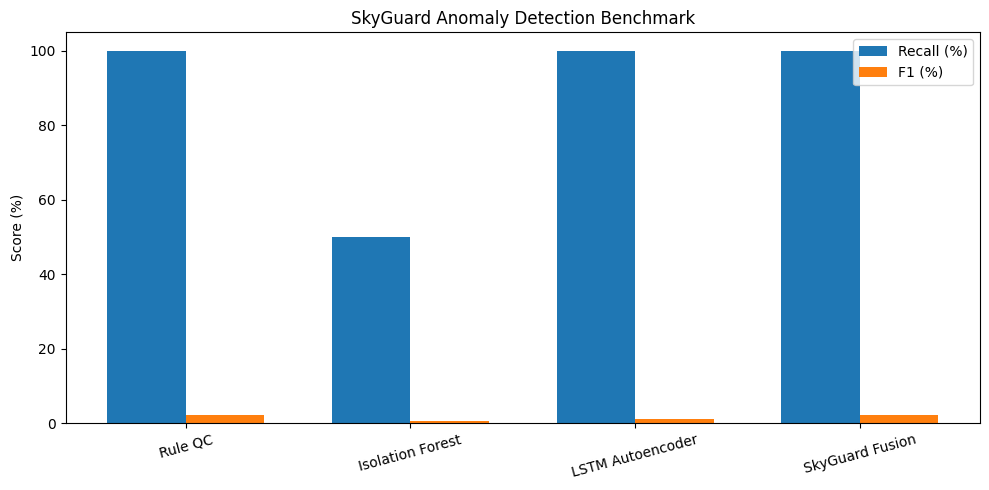

In [22]:
import matplotlib.pyplot as plt

methods = comparison["Method"]

recall_values = comparison["Recall (%)"]
f1_values = comparison["F1 (%)"]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width/2,
    recall_values,
    width,
    label="Recall (%)"
)

plt.bar(
    x + width/2,
    f1_values,
    width,
    label="F1 (%)"
)

plt.xticks(x, methods, rotation=15)
plt.ylabel("Score (%)")
plt.title("SkyGuard Anomaly Detection Benchmark")
plt.legend()
plt.tight_layout()
plt.show()

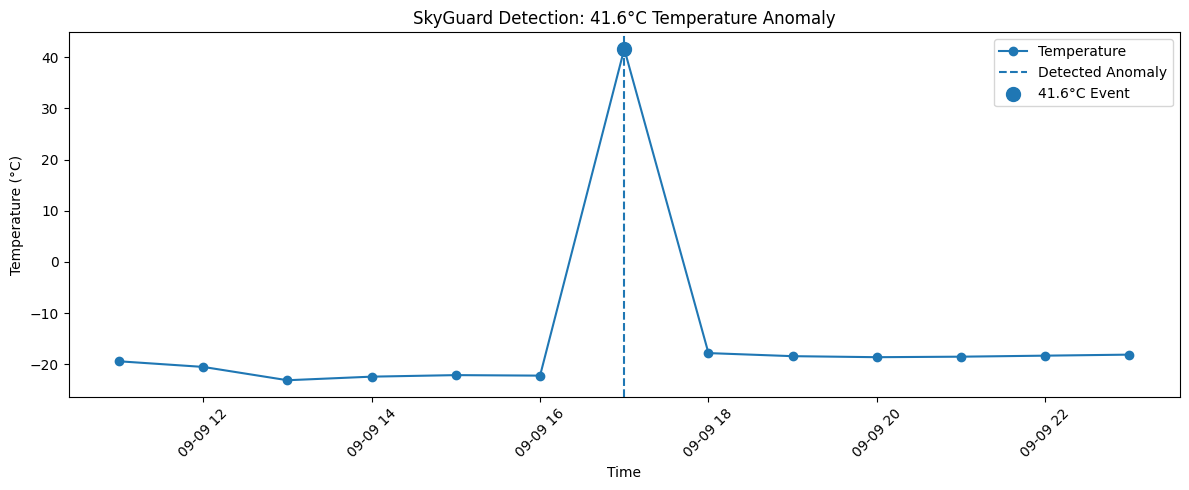

In [23]:
event_time = pd.Timestamp("2016-09-09 17:00:00")

event_window = skyguard_df[
    (skyguard_df["TIMESTAMP"] >= event_time - pd.Timedelta(hours=6)) &
    (skyguard_df["TIMESTAMP"] <= event_time + pd.Timedelta(hours=6))
].copy()

plt.figure(figsize=(12, 5))

plt.plot(
    event_window["TIMESTAMP"],
    event_window["TEMPERATURE"],
    marker="o",
    label="Temperature"
)

plt.axvline(
    event_time,
    linestyle="--",
    label="Detected Anomaly"
)

plt.scatter(
    [event_time],
    [41.6],
    s=100,
    zorder=5,
    label="41.6°C Event"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("SkyGuard Detection: 41.6°C Temperature Anomaly")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

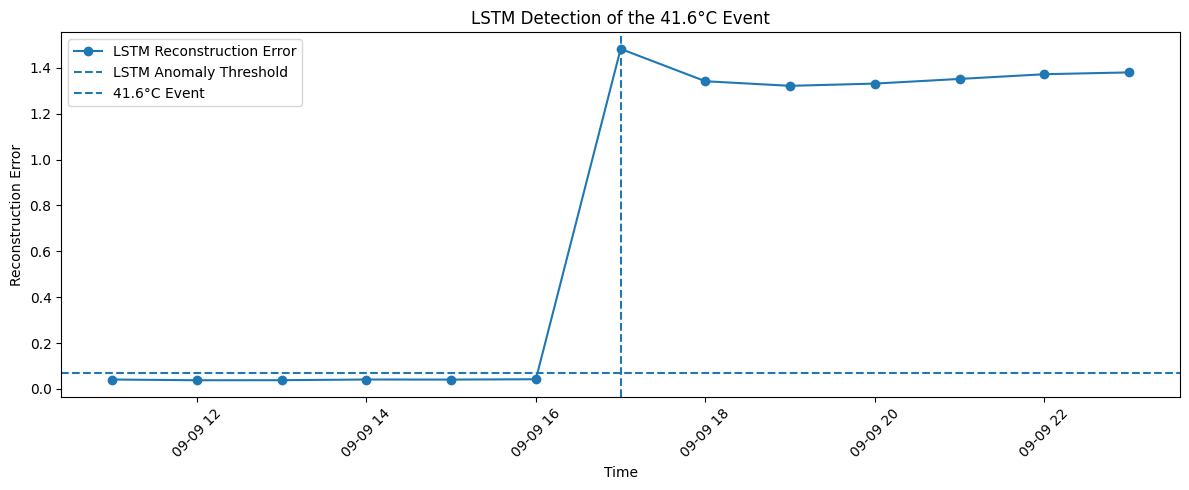

In [24]:
# LSTM reconstruction around the 41.6°C event

event_time = pd.Timestamp("2016-09-09 17:00:00")

event_lstm = lstm_test_results[
    (lstm_test_results["SEQUENCE_END"] >= event_time - pd.Timedelta(hours=6)) &
    (lstm_test_results["SEQUENCE_END"] <= event_time + pd.Timedelta(hours=6))
].copy()

plt.figure(figsize=(12, 5))

plt.plot(
    event_lstm["SEQUENCE_END"],
    event_lstm["LSTM_ERROR"],
    marker="o",
    label="LSTM Reconstruction Error"
)

plt.axhline(
    LSTM_THRESHOLD,
    linestyle="--",
    label="LSTM Anomaly Threshold"
)

plt.axvline(
    event_time,
    linestyle="--",
    label="41.6°C Event"
)

plt.xlabel("Time")
plt.ylabel("Reconstruction Error")
plt.title("LSTM Detection of the 41.6°C Event")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 15. Save ML Artifacts

In [25]:
from pathlib import Path

ARTIFACT_DIR = Path("skyguard_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

print("Artifact directory:", ARTIFACT_DIR.resolve())

Artifact directory: D:\user\Documents\jupyter notebook\SkyGuardAI\skyguard_artifacts


In [26]:
import joblib

joblib.dump(
    isolation_forest,
    ARTIFACT_DIR / "isolation_forest.joblib"
)

joblib.dump(
    scaler,
    ARTIFACT_DIR / "isolation_forest_scaler.joblib"
)

print("Isolation Forest artifacts saved.")

Isolation Forest artifacts saved.


In [27]:
lstm_autoencoder.save(
    ARTIFACT_DIR / "lstm_autoencoder.keras"
)

joblib.dump(
    lstm_scaler,
    ARTIFACT_DIR / "lstm_scaler.joblib"
)

joblib.dump(
    LSTM_THRESHOLD,
    ARTIFACT_DIR / "lstm_threshold.joblib"
)

print("LSTM artifacts saved.")

LSTM artifacts saved.


In [28]:
import json

feature_config = {
    "isolation_forest_features": ml_feature_cols,
    "lstm_features": lstm_features,
    "sequence_length": SEQUENCE_LENGTH,
    "lstm_threshold": float(LSTM_THRESHOLD)
}

with open(
    ARTIFACT_DIR / "feature_config.json",
    "w"
) as f:
    json.dump(feature_config, f, indent=4)

print("Feature configuration saved.")

Feature configuration saved.


In [29]:
print("\nSaved artifacts:")

for file in ARTIFACT_DIR.iterdir():
    print("-", file.name)


Saved artifacts:
- .ipynb_checkpoints
- feature_config.json
- isolation_forest.joblib
- isolation_forest_scaler.joblib
- lstm_autoencoder.keras
- lstm_scaler.joblib
- lstm_threshold.joblib


## 16. Reusable SkyGuard Inference Pipeline

In [30]:
class SkyGuardPipeline:

    def __init__(
        self,
        isolation_forest,
        isolation_scaler,
        lstm_model,
        lstm_scaler,
        lstm_threshold,
        sequence_length=24
    ):
        self.isolation_forest = isolation_forest
        self.isolation_scaler = isolation_scaler
        self.lstm_model = lstm_model
        self.lstm_scaler = lstm_scaler
        self.lstm_threshold = lstm_threshold
        self.sequence_length = sequence_length

    def check_input(self, data):

        required_columns = [
            "TIMESTAMP",
            "TEMPERATURE",
            "PRESSURE",
            "HUMIDITY"
        ]

        missing = [
            col for col in required_columns
            if col not in data.columns
        ]

        if missing:
            raise ValueError(
                f"Missing required columns: {missing}"
            )

        if len(data) < self.sequence_length:
            raise ValueError(
                f"At least {self.sequence_length} observations "
                f"are required for LSTM inference."
            )

        return True

    def create_ml_features(self, data):

        data = data.copy()

        data["TIMESTAMP"] = pd.to_datetime(data["TIMESTAMP"])
        data = data.sort_values("TIMESTAMP").reset_index(drop=True)

        # Time difference
        data["TIME_DIFF"] = data["TIMESTAMP"].diff()

        # Changes
        data["TEMP_CHANGE"] = data["TEMPERATURE"].diff()
        data["PRESSURE_CHANGE"] = data["PRESSURE"].diff()
        data["HUMIDITY_CHANGE"] = data["HUMIDITY"].diff()

        # Ignore changes across time gaps
        valid_hour = (
            data["TIME_DIFF"] == pd.Timedelta(hours=1)
        )

        data.loc[
            ~valid_hour,
            [
                "TEMP_CHANGE",
                "PRESSURE_CHANGE",
                "HUMIDITY_CHANGE"
            ]
        ] = np.nan

        # 3-hour rolling statistics
        data["TEMP_ROLLING_MEAN_3H"] = (
            data["TEMPERATURE"]
            .rolling(3, min_periods=3)
            .mean()
        )

        data["TEMP_ROLLING_STD_3H"] = (
            data["TEMPERATURE"]
            .rolling(3, min_periods=3)
            .std()
        )

        data["PRESSURE_ROLLING_MEAN_3H"] = (
            data["PRESSURE"]
            .rolling(3, min_periods=3)
            .mean()
        )

        data["PRESSURE_ROLLING_STD_3H"] = (
            data["PRESSURE"]
            .rolling(3, min_periods=3)
            .std()
        )

        data["HUMIDITY_ROLLING_MEAN_3H"] = (
            data["HUMIDITY"]
            .rolling(3, min_periods=3)
            .mean()
        )

        data["HUMIDITY_ROLLING_STD_3H"] = (
            data["HUMIDITY"]
            .rolling(3, min_periods=3)
            .std()
        )

        # Time features
        data["HOUR"] = data["TIMESTAMP"].dt.hour
        data["DAY_OF_YEAR"] = data["TIMESTAMP"].dt.dayofyear

        data["HOUR_SIN"] = np.sin(
            2 * np.pi * data["HOUR"] / 24
        )

        data["HOUR_COS"] = np.cos(
            2 * np.pi * data["HOUR"] / 24
        )

        data["DAY_SIN"] = np.sin(
            2 * np.pi * data["DAY_OF_YEAR"] / 365
        )

        data["DAY_COS"] = np.cos(
            2 * np.pi * data["DAY_OF_YEAR"] / 365
        )

        return data

    def pipeline_qc(self, data):

        data = data.copy()

        # Plausibility ranges
        data["TEMP_RANGE_FLAG"] = (
            (data["TEMPERATURE"] < -40) |
            (data["TEMPERATURE"] > 70)
        )

        data["PRESSURE_RANGE_FLAG"] = (
            (data["PRESSURE"] < 300) |
            (data["PRESSURE"] > 1250)
        )

        data["HUMIDITY_RANGE_FLAG"] = (
            (data["HUMIDITY"] < 0) |
            (data["HUMIDITY"] > 100)
        )

        # Changes
        data["TEMP_CHANGE"] = data["TEMPERATURE"].diff()
        data["PRESSURE_CHANGE"] = data["PRESSURE"].diff()
        data["HUMIDITY_CHANGE"] = data["HUMIDITY"].diff()

        # Rate-of-change checks
        data["TEMP_RATE_FLAG"] = (
            data["TEMP_CHANGE"].abs() > 3.5
        )

        data["PRESSURE_RATE_FLAG"] = (
            data["PRESSURE_CHANGE"].abs() > 2.7
        )

        data["HUMIDITY_RATE_FLAG"] = (
            data["HUMIDITY_CHANGE"].abs() > 20
        )

        data["QC_FLAG"] = (
            data["TEMP_RANGE_FLAG"] |
            data["PRESSURE_RANGE_FLAG"] |
            data["HUMIDITY_RANGE_FLAG"] |
            data["TEMP_RATE_FLAG"] |
            data["PRESSURE_RATE_FLAG"] |
            data["HUMIDITY_RATE_FLAG"]
        )

        return data

    def isolation_forest_inference(self, data):

        data = data.copy()

        features = ml_feature_cols

        missing = [
            col for col in features
            if col not in data.columns
        ]

        if missing:
            raise ValueError(
                f"Missing Isolation Forest features: {missing}"
            )

        valid_mask = data[features].notna().all(axis=1)

        data["IF_ANOMALY"] = False
        data["IF_SCORE"] = np.nan
        data["IF_PREDICTION"] = 1

        if valid_mask.any():

            X = data.loc[valid_mask, features]

            X_scaled = self.isolation_scaler.transform(X)

            predictions = self.isolation_forest.predict(
                X_scaled
            )

            scores = self.isolation_forest.decision_function(
                X_scaled
            )

            data.loc[
                valid_mask,
                "IF_PREDICTION"
            ] = predictions

            data.loc[
                valid_mask,
                "IF_SCORE"
            ] = scores

            data.loc[
                valid_mask,
                "IF_ANOMALY"
            ] = predictions == -1

        return data

    def lstm_inference(self, data):

        data = data.copy()

        features = [
            "TEMPERATURE",
            "PRESSURE",
            "HUMIDITY"
        ]

        missing = [
            col for col in features
            if col not in data.columns
        ]

        if missing:
            raise ValueError(
                f"Missing LSTM features: {missing}"
            )

        data["LSTM_ERROR"] = np.nan
        data["LSTM_ANOMALY"] = False

        # Need enough observations for one sequence
        if len(data) < self.sequence_length:
            return data

        valid_mask = data[features].notna().all(axis=1)

        if valid_mask.sum() < self.sequence_length:
            return data

        valid_data = data.loc[valid_mask].copy()

        # Scale using the scaler fitted during LSTM training
        X_scaled = self.lstm_scaler.transform(
            valid_data[features]
        )

        # Create sequences
        sequences = []

        sequence_indices = []

        for i in range(
            len(X_scaled) - self.sequence_length + 1
        ):

            sequences.append(
                X_scaled[
                    i:i + self.sequence_length
                ]
            )

            sequence_indices.append(
                valid_data.index[
                    i + self.sequence_length - 1
                ]
            )

        if not sequences:
            return data

        X_sequences = np.array(sequences)

        # LSTM reconstruction
        reconstructed = self.lstm_model.predict(
            X_sequences,
            verbose=0
        )

        # Reconstruction error
        errors = np.mean(
            np.square(
                X_sequences - reconstructed
            ),
            axis=(1, 2)
        )

        # Map error to sequence-end observation
        for idx, error in zip(
            sequence_indices,
            errors
        ):
            data.loc[
                idx,
                "LSTM_ERROR"
            ] = error

        # LSTM anomaly decision
        data.loc[
            data["LSTM_ERROR"].notna(),
            "LSTM_ANOMALY"
        ] = (
            data.loc[
                data["LSTM_ERROR"].notna(),
                "LSTM_ERROR"
            ] > self.lstm_threshold
        )

        return data

    def multivariate_consistency(self, data):

        data = data.copy()
    
        required_columns = [
            "TEMP_CHANGE",
            "PRESSURE_CHANGE",
            "HUMIDITY_CHANGE"
        ]
    
        missing = [
            col for col in required_columns
            if col not in data.columns
        ]
    
        if missing:
            raise ValueError(
                f"Missing multivariate features: {missing}"
            )
    
        # Standardize the changes
        temp_std = data["TEMP_CHANGE"].std()
        pressure_std = data["PRESSURE_CHANGE"].std()
        humidity_std = data["HUMIDITY_CHANGE"].std()
    
        temp_mean = data["TEMP_CHANGE"].mean()
        pressure_mean = data["PRESSURE_CHANGE"].mean()
        humidity_mean = data["HUMIDITY_CHANGE"].mean()
    
        data["TEMP_CHANGE_Z"] = (
            (data["TEMP_CHANGE"] - temp_mean) /
            temp_std
        )
    
        data["PRESSURE_CHANGE_Z"] = (
            (data["PRESSURE_CHANGE"] - pressure_mean) /
            pressure_std
        )
    
        data["HUMIDITY_CHANGE_Z"] = (
            (data["HUMIDITY_CHANGE"] - humidity_mean) /
            humidity_std
        )
    
        # Combined multivariate inconsistency score
        data["MULTIVARIATE_CHANGE_SCORE"] = np.sqrt(
            data["TEMP_CHANGE_Z"] ** 2 +
            data["PRESSURE_CHANGE_Z"] ** 2 +
            data["HUMIDITY_CHANGE_Z"] ** 2
        )
    
        # Flag unusually inconsistent T/P/RH changes
        data["MULTIVARIATE_ANOMALY"] = (
            data["MULTIVARIATE_CHANGE_SCORE"] > 3
        )
    
        return data
        

    def evidence_fusion(self, data):

        data = data.copy()

        required_columns = [
            "QC_FLAG",
            "IF_ANOMALY",
            "LSTM_ANOMALY",
            "MULTIVARIATE_ANOMALY"
        ]

        missing = [
            col for col in required_columns
            if col not in data.columns
        ]
    
        if missing:
            raise ValueError(
                f"Missing evidence columns: {missing}"
            )
    
        # Convert evidence signals to boolean
        data["QC_EVIDENCE"] = (
            data["QC_FLAG"]
            .fillna(False)
            .astype(bool)
        )
    
        data["IF_EVIDENCE"] = (
            data["IF_ANOMALY"]
            .fillna(False)
            .astype(bool)
        )
    
        data["LSTM_EVIDENCE"] = (
            data["LSTM_ANOMALY"]
            .fillna(False)
            .astype(bool)
        )
    
        data["MULTIVARIATE_EVIDENCE"] = (
            data["MULTIVARIATE_ANOMALY"]
            .fillna(False)
            .astype(bool)
        )
    
        # Count available evidence
        data["EVIDENCE_COUNT"] = (
            data["QC_EVIDENCE"].astype(int)
            + data["IF_EVIDENCE"].astype(int)
            + data["LSTM_EVIDENCE"].astype(int)
            + data["MULTIVARIATE_EVIDENCE"].astype(int)
        )
    
        # Final anomaly decision: 2 or more independent signals
        data["FINAL_ANOMALY"] = (
            data["EVIDENCE_COUNT"] >= 2
        )
    
        # Classification
        def classify(row):
    
            count = row["EVIDENCE_COUNT"]
    
            if count == 0:
                return "Normal"
    
            # Strong agreement between multiple detectors
            if count >= 3:
                return "Likely Sensor/Data Fault"
    
            # Two independent signals agree
            if count == 2:
                return "Uncertain"
    
            # Only one detector/evidence source
            return "Uncertain"
    
        data["FINAL_CLASSIFICATION"] = (
            data.apply(classify, axis=1)
        )
    
        return data

    def generate_explanation(self, data):

        data = data.copy()
    
        def explain(row):
    
            reasons = []
    
            # Rule-based QC
            if row.get("QC_EVIDENCE", False):
                reasons.append(
                    "Rule-based quality checks flagged the observation"
                )
    
            # Isolation Forest
            if row.get("IF_EVIDENCE", False):
                reasons.append(
                    "Isolation Forest detected an unusual multivariate pattern"
                )
    
            # LSTM
            if row.get("LSTM_EVIDENCE", False):
                reasons.append(
                    "LSTM detected an abnormal temporal pattern"
                )
    
            # T/P/RH consistency
            if row.get("MULTIVARIATE_EVIDENCE", False):
                reasons.append(
                    "Temperature, pressure and humidity changes were inconsistent"
                )
    
            # No evidence
            if not reasons:
                return "No significant anomaly evidence detected"
    
            return "; ".join(reasons)
    
        data["EXPLANATION"] = data.apply(
            explain,
            axis=1
        )
    
        return data

    def recovery_estimation(self, data):

        data = data.copy()
    
        data["ESTIMATED_TEMPERATURE"] = np.nan
        data["RECOVERY_METHOD"] = None
        data["RECOVERY_AVAILABLE"] = False
    
        anomaly_mask = data["FINAL_ANOMALY"] == True
    
        for idx in data.index[anomaly_mask]:
    
            # Need previous and next observations
            if idx - 1 in data.index and idx + 1 in data.index:
    
                previous_temp = data.loc[idx - 1, "TEMPERATURE"]
                next_temp = data.loc[idx + 1, "TEMPERATURE"]
    
                if pd.notna(previous_temp) and pd.notna(next_temp):
    
                    estimated_temp = (
                        previous_temp + next_temp
                    ) / 2
    
                    data.loc[
                        idx,
                        "ESTIMATED_TEMPERATURE"
                    ] = estimated_temp
    
                    data.loc[
                        idx,
                        "RECOVERY_METHOD"
                    ] = "Neighbor interpolation"
    
                    data.loc[
                        idx,
                        "RECOVERY_AVAILABLE"
                    ] = True
    
        return data

    def add_sensor_health(self, data, health_score):
        data = data.copy()
    
        data["SENSOR_HEALTH_SCORE"] = float(health_score)
    
        return data

    def run(self, data, health_score=None):

        # 1. Validate input
        self.check_input(data)
    
        # 2. Create ML features
        data = self.create_ml_features(data)
    
        # 3. Rule-based QC
        data = self.pipeline_qc(data)
    
        # 4. Isolation Forest
        data = self.isolation_forest_inference(data)
    
        # 5. LSTM inference
        data = self.lstm_inference(data)
    
        # 6. Multivariate consistency
        data = self.multivariate_consistency(data)
    
        # 7. Evidence fusion
        data = self.evidence_fusion(data)
    
        # 8. Explanation
        data = self.generate_explanation(data)
    
        # 9. Recovery / estimation
        data = self.recovery_estimation(data)
    
        # 10. Sensor health
        if health_score is not None:
            data = self.add_sensor_health(
                data,
                health_score
            )
    
        return data

print("SkyGuardPipeline class updated successfully.")

SkyGuardPipeline class updated successfully.


In [31]:
skyguard_pipeline = SkyGuardPipeline(
    isolation_forest=isolation_forest,
    isolation_scaler=scaler,
    lstm_model=lstm_autoencoder,
    lstm_scaler=lstm_scaler,
    lstm_threshold=LSTM_THRESHOLD,
    sequence_length=SEQUENCE_LENGTH
)

print("SkyGuard pipeline reinitialized successfully.")

SkyGuard pipeline reinitialized successfully.


### End-to-End Pipeline Test

In [32]:
pipeline_final_test = skyguard_df[
    (skyguard_df["TIMESTAMP"] >= "2016-09-08 00:00:00") &
    (skyguard_df["TIMESTAMP"] <= "2016-09-10 23:00:00")
].copy()

pipeline_final_test = skyguard_pipeline.run(
    pipeline_final_test,
    health_score=sensor_health_score
)

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [33]:
print(
    pipeline_final_test[
        pipeline_final_test["TIMESTAMP"] == "2016-09-09 17:00:00"
    ][
        [
            "TIMESTAMP",
            "TEMPERATURE",
            "QC_FLAG",
            "IF_ANOMALY",
            "LSTM_ANOMALY",
            "MULTIVARIATE_ANOMALY",
            "EVIDENCE_COUNT",
            "FINAL_ANOMALY",
            "FINAL_CLASSIFICATION",
            "EXPLANATION",
            "ESTIMATED_TEMPERATURE",
            "SENSOR_HEALTH_SCORE"
        ]
    ].to_string(index=False)
)

          TIMESTAMP  TEMPERATURE  QC_FLAG  IF_ANOMALY  LSTM_ANOMALY  MULTIVARIATE_ANOMALY  EVIDENCE_COUNT  FINAL_ANOMALY     FINAL_CLASSIFICATION                                                                                                                                                                                                            EXPLANATION  ESTIMATED_TEMPERATURE  SENSOR_HEALTH_SCORE
2016-09-09 17:00:00         41.6     True        True          True                  True               4           True Likely Sensor/Data Fault Rule-based quality checks flagged the observation; Isolation Forest detected an unusual multivariate pattern; LSTM detected an abnormal temporal pattern; Temperature, pressure and humidity changes were inconsistent                  -20.0            96.231985


## 17. Final Evaluation and Output

In [34]:
# Use the dynamically computed benchmark comparison.
final_comparison = comparison.copy()

print(final_comparison.to_string(index=False))

print(
    "\nBenchmark note:"
    "\nThe evaluation uses 10 controlled injected anomalies "
    "to verify anomaly-detection behavior."
    "\nThese results are a prototype benchmark and should not "
    "be interpreted as production-level performance."
)


          Method  Precision (%)  Recall (%)  F1 (%)  Detected
         Rule QC           1.04       100.0    2.06       959
Isolation Forest           0.26        50.0    0.51      1943
LSTM Autoencoder           0.50       100.0    1.00      1997
 SkyGuard Fusion           1.03       100.0    2.04       971

Benchmark note:
The evaluation uses 10 controlled injected anomalies to verify anomaly-detection behavior.
These results are a prototype benchmark and should not be interpreted as production-level performance.


In [35]:
event_result = pipeline_final_test[
    pipeline_final_test["TIMESTAMP"] == "2016-09-09 17:00:00"
][
    [
        "TIMESTAMP",
        "TEMPERATURE",
        "QC_FLAG",
        "IF_ANOMALY",
        "LSTM_ANOMALY",
        "MULTIVARIATE_ANOMALY",
        "EVIDENCE_COUNT",
        "FINAL_ANOMALY",
        "FINAL_CLASSIFICATION",
        "ESTIMATED_TEMPERATURE",
        "SENSOR_HEALTH_SCORE"
    ]
]

print(event_result.to_string(index=False))

          TIMESTAMP  TEMPERATURE  QC_FLAG  IF_ANOMALY  LSTM_ANOMALY  MULTIVARIATE_ANOMALY  EVIDENCE_COUNT  FINAL_ANOMALY     FINAL_CLASSIFICATION  ESTIMATED_TEMPERATURE  SENSOR_HEALTH_SCORE
2016-09-09 17:00:00         41.6     True        True          True                  True               4           True Likely Sensor/Data Fault                  -20.0            96.231985


In [36]:
print(
    pipeline_final_test["FINAL_CLASSIFICATION"].value_counts()
)

FINAL_CLASSIFICATION
Uncertain                   59
Normal                      11
Likely Sensor/Data Fault     2
Name: count, dtype: int64


In [37]:
print(
    "\nFinal anomaly count:",
    pipeline_final_test["FINAL_ANOMALY"].sum()
)

print(
    "Total observations:",
    len(pipeline_final_test)
)


Final anomaly count: 7
Total observations: 72


In [38]:
final_output_cols = [
    "TIMESTAMP",
    "TEMPERATURE",
    "PRESSURE",
    "HUMIDITY",
    "QC_FLAG",
    "IF_ANOMALY",
    "LSTM_ANOMALY",
    "MULTIVARIATE_ANOMALY",
    "EVIDENCE_COUNT",
    "FINAL_ANOMALY",
    "FINAL_CLASSIFICATION",
    "EXPLANATION",
    "ESTIMATED_TEMPERATURE",
    "RECOVERY_METHOD",
    "RECOVERY_AVAILABLE",
    "SENSOR_HEALTH_SCORE"
]

final_output = pipeline_final_test[
    [col for col in final_output_cols if col in pipeline_final_test.columns]
].copy()

print("Final output shape:", final_output.shape)
print("\nColumns:")
print(final_output.columns.tolist())

Final output shape: (72, 16)

Columns:
['TIMESTAMP', 'TEMPERATURE', 'PRESSURE', 'HUMIDITY', 'QC_FLAG', 'IF_ANOMALY', 'LSTM_ANOMALY', 'MULTIVARIATE_ANOMALY', 'EVIDENCE_COUNT', 'FINAL_ANOMALY', 'FINAL_CLASSIFICATION', 'EXPLANATION', 'ESTIMATED_TEMPERATURE', 'RECOVERY_METHOD', 'RECOVERY_AVAILABLE', 'SENSOR_HEALTH_SCORE']


In [39]:
OUTPUT_FILE = "skyguard_final_demo_results.csv"

final_output.to_csv(
    OUTPUT_FILE,
    index=False
)

print(f"\nSaved: {OUTPUT_FILE}")


Saved: skyguard_final_demo_results.csv


In [40]:
print(
    final_output[
        final_output["TIMESTAMP"] == "2016-09-09 17:00:00"
    ].to_string(index=False)
)

          TIMESTAMP  TEMPERATURE  PRESSURE  HUMIDITY  QC_FLAG  IF_ANOMALY  LSTM_ANOMALY  MULTIVARIATE_ANOMALY  EVIDENCE_COUNT  FINAL_ANOMALY     FINAL_CLASSIFICATION                                                                                                                                                                                                            EXPLANATION  ESTIMATED_TEMPERATURE        RECOVERY_METHOD  RECOVERY_AVAILABLE  SENSOR_HEALTH_SCORE
2016-09-09 17:00:00         41.6     946.7     100.0     True        True          True                  True               4           True Likely Sensor/Data Fault Rule-based quality checks flagged the observation; Isolation Forest detected an unusual multivariate pattern; LSTM detected an abnormal temporal pattern; Temperature, pressure and humidity changes were inconsistent                  -20.0 Neighbor interpolation                True            96.231985


## 18. Model Reload Verification

In [41]:
import joblib
from tensorflow.keras.models import load_model

# Reload Isolation Forest
loaded_isolation_forest = joblib.load(
    ARTIFACT_DIR / "isolation_forest.joblib"
)

# Reload Isolation Forest scaler
loaded_isolation_scaler = joblib.load(
    ARTIFACT_DIR / "isolation_forest_scaler.joblib"
)

# Reload LSTM model
loaded_lstm_model = load_model(
    ARTIFACT_DIR / "lstm_autoencoder.keras"
)

# Reload LSTM scaler
loaded_lstm_scaler = joblib.load(
    ARTIFACT_DIR / "lstm_scaler.joblib"
)

# Reload LSTM threshold
loaded_lstm_threshold = joblib.load(
    ARTIFACT_DIR / "lstm_threshold.joblib"
)

print("All saved artifacts loaded successfully.")
print("LSTM threshold:", loaded_lstm_threshold)

All saved artifacts loaded successfully.
LSTM threshold: 0.07097852191878912


In [42]:
loaded_pipeline = SkyGuardPipeline(
    isolation_forest=loaded_isolation_forest,
    isolation_scaler=loaded_isolation_scaler,
    lstm_model=loaded_lstm_model,
    lstm_scaler=loaded_lstm_scaler,
    lstm_threshold=loaded_lstm_threshold,
    sequence_length=SEQUENCE_LENGTH
)

print("Reloaded SkyGuard pipeline created successfully.")

Reloaded SkyGuard pipeline created successfully.


In [43]:
reload_test = skyguard_df[
    (skyguard_df["TIMESTAMP"] >= "2016-09-08 00:00:00") &
    (skyguard_df["TIMESTAMP"] <= "2016-09-10 23:00:00")
].copy()

reload_test = loaded_pipeline.create_ml_features(
    reload_test
)

reload_test = loaded_pipeline.isolation_forest_inference(
    reload_test
)

print(
    reload_test[
        reload_test["TIMESTAMP"] == "2016-09-09 17:00:00"
    ][
        [
            "TIMESTAMP",
            "TEMPERATURE",
            "IF_PREDICTION",
            "IF_SCORE",
            "IF_ANOMALY"
        ]
    ].to_string(index=False)
)


          TIMESTAMP  TEMPERATURE  IF_PREDICTION  IF_SCORE  IF_ANOMALY
2016-09-09 17:00:00         41.6             -1 -0.188275        True


In [44]:
reload_test = loaded_pipeline.lstm_inference(
    reload_test
)

print(
    reload_test[
        reload_test["TIMESTAMP"] == "2016-09-09 17:00:00"
    ][
        [
            "TIMESTAMP",
            "TEMPERATURE",
            "LSTM_ERROR",
            "LSTM_ANOMALY"
        ]
    ].to_string(index=False)
)

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


          TIMESTAMP  TEMPERATURE  LSTM_ERROR  LSTM_ANOMALY
2016-09-09 17:00:00         41.6    1.482432          True


## 19. Final Prototype Summary

In [45]:
print("=" * 60)
print("SKYGUARD AI — FINAL PROTOTYPE SUMMARY")
print("=" * 60)

print("\nDATASET")
print("- Total observations:", len(skyguard_df))
print("- Time range:",
      skyguard_df["TIMESTAMP"].min(),
      "to",
      skyguard_df["TIMESTAMP"].max())

print("\nQUALITY CONTROL")
print("- Observations with QC issues:",
      int(skyguard_df["QC_FLAG"].sum()))

print("\nSENSOR HEALTH")
print("- Overall Sensor Health Score:",
      round(sensor_health_score, 2), "/ 100")

print("\nCONTROLLED BENCHMARK")
print("- Injected anomalies:", 10)

print("\nMODEL COMPARISON")
print(final_comparison.to_string(index=False))

print("\nREAL DATA CASE STUDY")
event = pipeline_final_test[
    pipeline_final_test["TIMESTAMP"] == "2016-09-09 17:00:00"
].iloc[0]

print("- Timestamp:", event["TIMESTAMP"])
print("- Original temperature:", event["TEMPERATURE"], "°C")
print("- QC anomaly:", event["QC_FLAG"])
print("- Isolation Forest:", event["IF_ANOMALY"])
print("- LSTM:", event["LSTM_ANOMALY"])
print("- Multivariate:", event["MULTIVARIATE_ANOMALY"])
print("- Evidence count:", event["EVIDENCE_COUNT"])
print("- Final classification:", event["FINAL_CLASSIFICATION"])
print("- Estimated temperature:",
      event["ESTIMATED_TEMPERATURE"], "°C")

print("\nARTIFACTS")
for file in ARTIFACT_DIR.iterdir():
    print("-", file.name)

print("\nFINAL OUTPUT")
print("- CSV:", OUTPUT_FILE)
print("- JSON: skyguard_final_results.json")

print("\n" + "=" * 60)


SKYGUARD AI — FINAL PROTOTYPE SUMMARY

DATASET
- Total observations: 16514
- Time range: 2015-01-01 00:00:00 to 2016-12-19 12:00:00

QUALITY CONTROL
- Observations with QC issues: 953

SENSOR HEALTH
- Overall Sensor Health Score: 96.23 / 100

CONTROLLED BENCHMARK
- Injected anomalies: 10

MODEL COMPARISON
          Method  Precision (%)  Recall (%)  F1 (%)  Detected
         Rule QC           1.04       100.0    2.06       959
Isolation Forest           0.26        50.0    0.51      1943
LSTM Autoencoder           0.50       100.0    1.00      1997
 SkyGuard Fusion           1.03       100.0    2.04       971

REAL DATA CASE STUDY
- Timestamp: 2016-09-09 17:00:00
- Original temperature: 41.6 °C
- QC anomaly: True
- Isolation Forest: True
- LSTM: True
- Multivariate: True
- Evidence count: 4
- Final classification: Likely Sensor/Data Fault
- Estimated temperature: -20.0 °C

ARTIFACTS
- .ipynb_checkpoints
- feature_config.json
- isolation_forest.joblib
- isolation_forest_scaler.joblib
- 

In [46]:
case_study = pd.DataFrame({
    "Parameter": [
        "Observed Temperature",
        "QC Evidence",
        "Isolation Forest",
        "LSTM Autoencoder",
        "Multivariate Consistency",
        "Evidence Count",
        "Final Classification",
        "Estimated Temperature",
        "Sensor Health"
    ],
    "Result": [
        f'{event["TEMPERATURE"]} °C',
        str(event["QC_FLAG"]),
        str(event["IF_ANOMALY"]),
        str(event["LSTM_ANOMALY"]),
        str(event["MULTIVARIATE_ANOMALY"]),
        f'{event["EVIDENCE_COUNT"]}/4',
        event["FINAL_CLASSIFICATION"],
        f'{event["ESTIMATED_TEMPERATURE"]} °C',
        f'{event["SENSOR_HEALTH_SCORE"]:.2f}/100'
    ]
})

print(case_study.to_string(index=False))

               Parameter                   Result
    Observed Temperature                  41.6 °C
             QC Evidence                     True
        Isolation Forest                     True
        LSTM Autoencoder                     True
Multivariate Consistency                     True
          Evidence Count                      4/4
    Final Classification Likely Sensor/Data Fault
   Estimated Temperature                 -20.0 °C
           Sensor Health                96.23/100


In [47]:
comparison_lookup = final_comparison.set_index("Method")

final_project_results = {
    "dataset_observations": int(len(skyguard_df)),
    "dataset_start": str(skyguard_df["TIMESTAMP"].min()),
    "dataset_end": str(skyguard_df["TIMESTAMP"].max()),
    "qc_flagged_observations": int(skyguard_df["QC_FLAG"].sum()),
    "sensor_health_score": round(float(sensor_health_score), 2),

    "benchmark_injected_anomalies": 10,

    "skyguard_precision": float(
        comparison_lookup.loc["SkyGuard Fusion", "Precision (%)"]
    ),
    "skyguard_recall": float(
        comparison_lookup.loc["SkyGuard Fusion", "Recall (%)"]
    ),
    "skyguard_f1": float(
        comparison_lookup.loc["SkyGuard Fusion", "F1 (%)"]
    ),
    "skyguard_detected": int(
        comparison_lookup.loc["SkyGuard Fusion", "Detected"]
    ),

    "case_study_timestamp": str(event["TIMESTAMP"]),
    "case_study_temperature": float(event["TEMPERATURE"]),
    "case_study_evidence_count": int(event["EVIDENCE_COUNT"]),
    "case_study_classification": str(event["FINAL_CLASSIFICATION"]),
    "case_study_estimated_temperature": float(
        event["ESTIMATED_TEMPERATURE"]
    )
}

print(final_project_results)


{'dataset_observations': 16514, 'dataset_start': '2015-01-01 00:00:00', 'dataset_end': '2016-12-19 12:00:00', 'qc_flagged_observations': 953, 'sensor_health_score': 96.23, 'benchmark_injected_anomalies': 10, 'skyguard_precision': 1.03, 'skyguard_recall': 100.0, 'skyguard_f1': 2.04, 'skyguard_detected': 971, 'case_study_timestamp': '2016-09-09 17:00:00', 'case_study_temperature': 41.6, 'case_study_evidence_count': 4, 'case_study_classification': 'Likely Sensor/Data Fault', 'case_study_estimated_temperature': -20.0}


In [48]:
import json

with open("skyguard_final_results.json", "w") as f:
    json.dump(final_project_results, f, indent=4)

print("Saved: skyguard_final_results.json")

Saved: skyguard_final_results.json


In [49]:
print("\nSkyGuard artifacts:")
for file in ARTIFACT_DIR.iterdir():
    print("-", file.name)

print("\nOutput files:")
print("- skyguard_final_demo_results.csv")
print("- skyguard_final_results.json")


SkyGuard artifacts:
- .ipynb_checkpoints
- feature_config.json
- isolation_forest.joblib
- isolation_forest_scaler.joblib
- lstm_autoencoder.keras
- lstm_scaler.joblib
- lstm_threshold.joblib

Output files:
- skyguard_final_demo_results.csv
- skyguard_final_results.json


## 20. Notes for Reuse

- Raw observations are never overwritten by estimated values.
- Large time gaps are not interpolated for LSTM sequence creation.
- Isolation Forest and LSTM scores are treated as separate evidence sources.
- Spatial evidence is explicitly marked unavailable for this single-station dataset.
- The controlled benchmark uses injected anomalies only for prototype validation.
- The 41.6°C observation is a real observation from the dataset; the final classification is evidence-based, not a claim of absolute ground truth.
